In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



/kaggle/input/datasets/nikhileswarkomati/suicide-watch/Suicide_Detection.csv
/kaggle/input/datasets/abhimanyousaharan/mtt-checkpoints/mtt_checkpoints/checkpoint_sklearn.pkl
/kaggle/input/datasets/abhimanyousaharan/mtt-checkpoints/mtt_checkpoints/checkpoint_dataframes.pkl
/kaggle/input/datasets/abhimanyousaharan/mtt-checkpoints/mtt_checkpoints/checkpoint_model_state.pt
/kaggle/input/datasets/abhimanyousaharan/mtt-checkpoints/mtt_checkpoints/checkpoint_metrics.pkl
/kaggle/input/datasets/abhimanyousaharan/mtt-checkpoints/mtt_checkpoints/checkpoint_predictions.npz
/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv


In [2]:

!pip install transformers datasets accelerate coral-pytorch contractions imbalanced-learn scikit-learn statsmodels -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 56.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-c

In [ ]:


import os
import re
import json
import math
import random
import warnings
import logging
from pathlib import Path
from typing import Optional, Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    cohen_kappa_score, mean_absolute_error, mean_squared_error
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
    logging as hf_logging,
)

from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch

try:
    import contractions
    HAS_CONTRACTIONS = True
except ImportError:
    HAS_CONTRACTIONS = False
    print("Warning: 'contractions' library not found.")

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)


SEED = 999

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = DEVICE
print(f"✅ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5


NUM_SENTIMENT_CLASSES = 3   # negative / neutral / positive
NUM_SEVERITY_CLASSES  = 4   # minimum / mild / moderate / severe

os.makedirs("/kaggle/working/mtt_checkpoints", exist_ok=True)
BEST_MODEL_PATH = "/kaggle/working/mtt_best_model.pt"


SENTIMENT_LABELS = {0: "negative", 1: "neutral", 2: "positive"}
SEVERITY_LABELS  = {0: "minimum",  1: "mild",    2: "moderate", 3: "severe"}

print("✅ Config ready")
print(f"   Sentiment classes : {NUM_SENTIMENT_CLASSES}")
print(f"   Severity  classes : {NUM_SEVERITY_CLASSES}")


✅ Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB
✅ Config ready
   Sentiment classes : 3
   Severity  classes : 4


In [4]:
import pandas as pd

sentiment_df = pd.read_csv(
   "/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv"
)

print(sentiment_df.head())
print(sentiment_df.shape)
print(sentiment_df['status'].value_counts())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
(53043, 3)
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [5]:
!git clone https://github.com/usmaann/Depression_Severity_Dataset.git /kaggle/working/dep_severity

Cloning into '/kaggle/working/dep_severity'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 612.32 KiB | 3.42 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [6]:
!git clone https://github.com/abuBakarSiddiqurRahman/DepressionEmo.git /kaggle/working/dep_emo

Cloning into '/kaggle/working/dep_emo'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 91 (delta 24), reused 6 (delta 6), pack-reused 54 (from 1)
Receiving objects: 100% (91/91), 2.05 MiB | 8.29 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [7]:
!ls

dep_emo  dep_severity  mtt_checkpoints


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SHARED KEYWORD LISTS  
# ─────────────────────────────────────────────────────────────────────────────
 
SUICIDE_KW = [
    'suicid', 'kill myself', 'end my life', 'want to die', 'take my own life',
    'end it all', 'no reason to live', 'better off dead', 'wanna die',
    'ending my life', 'self-harm', 'self harm', 'cutting myself', 'overdose',
    'hang myself', 'jump off', 'shoot myself', 'goodbye cruel world',
    'last note', 'farewell letter', 'no point living', 'ready to die',
    'planning to die', 'death wish', 'i want out of life',
]
 
SEVERE_KW = [
    'hopeless', 'worthless', 'emptiness', 'empty inside', 'numb inside',
    'completely broken', 'no way out', 'trapped', 'unbearable pain',
    'psychosis', 'hearing voices', 'see things', 'hallucin',
    'can\'t go on', 'cannot go on', 'no future', 'life is meaningless',
    'deeply depressed', 'severe depression', 'hospitaliz', 'hospitalised',
    'inpatient', 'psychiatric', 'breakdown', 'total breakdown',
    'nothing matters', 'lost all hope', 'completely hopeless',
    'i give up', 'giving up on life', 'i quit living',
]
 
MODERATE_KW = [
    'depress', 'depression', 'cry every day', 'crying all the time',
    'can\'t get out of bed', 'cannot get out of bed', 'lost interest',
    'no motivation', 'exhausted all the time', 'chronic fatigue',
    'panic attack', 'severe anxiety', 'trauma', 'ptsd', 'flashback',
    'can\'t sleep', 'cannot sleep', 'insomnia', 'nightmares',
    'self loathe', 'self hate', 'hate myself', 'worthless',
    'feel like a burden', 'nobody cares', 'completely alone',
    'haven\'t left the house', 'stopped eating', 'not eating',
    'dissociat', 'detached from reality', 'i feel nothing',
    'bipolar', 'manic episode', 'personality disorder',
    'overwhelmed and broken', 'can\'t function', 'cannot function',
    'dark thoughts', 'intrusive thoughts', 'urge to hurt',
]
 
MILD_KW = [
    'anxious', 'anxiety', 'nervous', 'worried', 'stress', 'stressed out',
    'overwhelm', 'sad', 'sadness', 'grief', 'lonely', 'loneliness',
    'upset', 'irritable', 'frustrated', 'unmotivated', 'low energy',
    'can\'t concentrate', 'cannot concentrate', 'brain fog',
    'trouble sleeping', 'sleep issues', 'restless', 'on edge',
    'feeling lost', 'confused', 'unsure about future', 'missing',
    'heartbreak', 'breakup', 'broke up', 'relationship ended',
    'feeling blue', 'down lately', 'not myself', 'off lately',
    'feeling disconnected', 'mood swings', 'irritated',
    'social anxiety', 'shy', 'fear of judgment', 'low self-esteem',
    'insecure', 'scared of', 'dread',
]
 
POSITIVE_KW = [
    'happy', 'grateful', 'better now', 'feeling good', 'doing well',
    'hopeful', 'progress', 'improve', 'recovery', 'recovering',
    'joy', 'joyful', 'excited', 'thriving', 'content', 'peaceful',
    'healed', 'healing journey', 'getting better', 'much better',
    'optimistic', 'positive outlook', 'motivated', 'energized',
    'love life', 'enjoying', 'looking forward', 'thankful', 'blessed',
]
 
 
def _contains_any(text_lower: str, keywords: list) -> bool:
    return any(kw in text_lower for kw in keywords)
 
 
def keyword_sentiment_severity(text: str,
                                default_sentiment: str = 'neutral',
                                default_severity: str = 'mild') -> tuple:
    """
    Hierarchical keyword-based labeller.
    Returns (sentiment, severity).
    Priority: suicide > severe > moderate > mild > positive > default
    """
    t = str(text).lower()
 
    if _contains_any(t, SUICIDE_KW):
        return 'negative', 'severe'
    if _contains_any(t, SEVERE_KW):
        return 'negative', 'severe'
    if _contains_any(t, MODERATE_KW):
        return 'negative', 'moderate'
    if _contains_any(t, MILD_KW):
       
        return 'negative', 'mild'
    if _contains_any(t, POSITIVE_KW):
        return 'positive', 'minimum'
 
    return default_sentiment, default_severity
 
 

In [ ]:
# =============================================================================
# ── Load Dataset 1 : Combined_Data.csv
# =============================================================================
 
sentiment_df = pd.read_csv(
    "/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv"
)
 
sentiment_df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
sentiment_df = sentiment_df.rename(columns={'statement': 'text', 'status': 'condition'})
 


positive_conditions = ['Normal']
negative_conditions = [
    'Depression', 'Suicidal', 'Bipolar', 'Personality disorder',
    'Anxiety', 'Stress'          
]
 
def map_sentiment_comb(condition):
    if condition in positive_conditions:
        return 'positive'
    elif condition in negative_conditions:
        return 'negative'
    else:
        return 'neutral'         
 
sentiment_df['sentiment'] = sentiment_df['condition'].apply(map_sentiment_comb)
 


severity_map_base = {
    'Normal'              : 'minimum',
    'Stress'              : 'mild',
    'Anxiety'             : 'mild',
    'Bipolar'             : 'moderate',
    'Personality disorder': 'moderate',
    'Suicidal'            : 'severe',
}
 
def map_severity_comb(row):
    cond = row['condition']
    if cond in severity_map_base:
        return severity_map_base[cond]
    if cond == 'Depression':
      
        t = str(row['text']).lower()
        if _contains_any(t, SUICIDE_KW + SEVERE_KW):
            return 'severe'
        return 'moderate'
    return 'mild'   
 
sentiment_df['severity'] = sentiment_df.apply(map_severity_comb, axis=1)
sentiment_df.drop(columns=['condition'], inplace=True)
 
print("\n Dataset 1 — Combined_Data.csv ")
print(sentiment_df.columns.tolist())
print(sentiment_df.head())
print(sentiment_df['sentiment'].value_counts())
print(sentiment_df['severity'].value_counts())
 



 Dataset 1 — Combined_Data.csv 
['text', 'sentiment', 'severity']
                                                text sentiment severity
0                                         oh my gosh  negative     mild
1  trouble sleeping, confused mind, restless hear...  negative     mild
2  All wrong, back off dear, forward doubt. Stay ...  negative     mild
3  I've shifted my focus to something else but I'...  negative     mild
4  I'm restless and restless, it's been a month n...  negative     mild
sentiment
negative    36692
positive    16351
Name: count, dtype: int64
severity
minimum     16351
moderate    15068
severe      15067
mild         6557
Name: count, dtype: int64


In [ ]:
# =============================================================================
# ──Load Dataset 2 : Reddit_depression_dataset.csv
# =============================================================================
 
severity_df = pd.read_csv(
    "/kaggle/working/dep_severity/Reddit_depression_dataset.csv"
)
 
print(severity_df['label'].value_counts())
print(severity_df.head())
print(severity_df.shape)
print(severity_df.columns.tolist())
 
severity_df = severity_df.rename(columns={'label': 'severity'})
severity_df['severity'] = severity_df['severity'].str.lower().str.strip()
 


def severity_to_sentiment_fixed(row):
    text = str(row.get('text', ''))
    sev  = row['severity']
 
  
    kw_sentiment, _ = keyword_sentiment_severity(text,
                                                  default_sentiment=None,
                                                  default_severity=None)
    if kw_sentiment is not None:
        return kw_sentiment
 
   
    if sev == 'minimum':
        return 'positive'
    elif sev in ['mild', 'moderate']:
        return 'neutral'
    else:   
        return 'negative'
 
severity_df['sentiment'] = severity_df.apply(severity_to_sentiment_fixed, axis=1)
severity_df = severity_df[['text', 'sentiment', 'severity']]
 
print("\n Dataset 2 — Reddit_depression_dataset ")
print(severity_df.columns.tolist())
print(severity_df.head())
print(severity_df['severity'].value_counts())
print(severity_df['sentiment'].value_counts())
 

label
minimum     2587
moderate     394
mild         290
severe       282
Name: count, dtype: int64
                                                text     label
0  He said he had not felt that way before, sugge...      mild
1  Hey there r/assistance, Not sure if this is th...   minimum
2  My mom then hit me with the newspaper and it s...   minimum
3  until i met my new boyfriend, he is amazing, h...      mild
4  October is Domestic Violence Awareness Month a...  moderate
(3553, 2)
['text', 'label']

 Dataset 2 — Reddit_depression_dataset 
['text', 'sentiment', 'severity']
                                                text sentiment  severity
0  He said he had not felt that way before, sugge...  negative      mild
1  Hey there r/assistance, Not sure if this is th...  positive   minimum
2  My mom then hit me with the newspaper and it s...  positive   minimum
3  until i met my new boyfriend, he is amazing, h...  positive      mild
4  October is Domestic Violence Awareness Month a...  

In [ ]:
# =============================================================================
# ── Load Dataset 3 : combined.json (DepressionEmo)
# =============================================================================
 
import ast
 
dep_emo_df = pd.read_json(
    "/kaggle/working/dep_emo/Dataset/combined.json",
    lines=True
)
 
print(dep_emo_df.head())
print(dep_emo_df.shape)
print(dep_emo_df.columns.tolist())
 
dep_emo_df.drop(columns=['id', 'upvotes', 'date'], inplace=True, errors='ignore')
dep_emo_df = dep_emo_df.rename(columns={'label_id': 'severity_label'})
 
def convert_to_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    x = str(x).strip().replace('"', '').replace("'", '')
    x = x.strip('[]')
    emotions = [e.strip().lower() for e in x.split(',') if e.strip()]
    return emotions
 
dep_emo_df['emotion_list'] = dep_emo_df['emotions'].apply(convert_to_list)
 

positive_emotions = {
    'joy': 2, 'love': 2, 'optimism': 2, 'gratitude': 2, 'hope': 2,
    'caring': 1, 'pride': 1, 'relief': 1, 'amusement': 1,
}
neutral_emotions = {
    'surprise', 'confusion', 'curiosity', 'realization', 'nervousness'
}
negative_emotions = {
    'sadness': -1, 'loneliness': -1, 'anger': -1, 'fear': -1, 'guilt': -1,
    'hopelessness': -2, 'worthlessness': -2, 'emptiness': -2,
    'self hate': -2, 'brain dysfunction (forget)': -2,
    'suicide intent': -3,
}
 
def map_sentiment_emo(emotion_list):
    score = 0
    for emo in emotion_list:
        emo = str(emo).strip().lower()
        if emo in positive_emotions:
            score += positive_emotions[emo]
        elif emo in negative_emotions:
            score += negative_emotions[emo]
       
    if score >= 2:
        return 'positive'
    elif score <= -2:
        return 'negative'
    else:
        return 'neutral'
 


def map_severity_emo(emotion_list):
    severity_score = 0
    has_suicide_intent = False
 
    for emo in emotion_list:
        emo = str(emo).strip().lower()
        if emo == 'suicide intent':
            has_suicide_intent = True
            severity_score += 5
        elif emo in ['worthlessness', 'self hate', 'hopelessness',
                     'emptiness', 'brain dysfunction (forget)']:
            severity_score += 3
        elif emo in ['sadness', 'loneliness', 'fear', 'anger', 'guilt']:
            severity_score += 1
 
    if has_suicide_intent or severity_score > 4:
        return 'severe'
    elif severity_score >= 3:      
        return 'moderate'
    elif severity_score >= 1:       
        return 'mild'
    else:
        return 'minimum'
 
dep_emo_df['sentiment'] = dep_emo_df['emotion_list'].apply(map_sentiment_emo)
dep_emo_df['severity']  = dep_emo_df['emotion_list'].apply(map_severity_emo)
 
dep_emo_df.drop(
    columns=['title', 'emotions', 'emotion_list', 'post', 'severity_label'],
    inplace=True, errors='ignore'
)
 
print("\n  Dataset 3 — DepressionEmo (combined.json) ")

print(dep_emo_df.head())
print(dep_emo_df.columns.tolist())
print(dep_emo_df['sentiment'].value_counts())
print(dep_emo_df['severity'].value_counts())
 

       id                                              title  \
0  hhcq6e                          Found out something awful   
1  d0bobn                I just want to feel wanted ya know?   
2  wy400i                                               Done   
3  crkjga  When nobody else celebrates you, learn to cele...   
4  zq1lwl                                           goodbye.   

                                                post  \
0  My mum had a boyfriend when I was around 6 or ...   
1  Like, I have a ton of friends, I talk to them ...   
2  I’m writing this as I sit on the side of the r...   
3  Feeling unloved can have a huge impact on the ...   
4  I'm done. I have a bottle of jack danials and ...   

                                                text  upvotes  \
0  Found out something awful ### My mum had a boy...     53.0   
1  I just want to feel wanted ya know? ### Like, ...     51.0   
2  Done ### I’m writing this as I sit on the side...      8.0   
3  When nobody els

In [ ]:
# =============================================================================
# ── reddit-depression-cleaned (HuggingFace)
# =============================================================================
 
from datasets import load_dataset
 
print("Loading reddit-depression-cleaned ...")
rd_cleaned = load_dataset("hugginglearners/reddit-depression-cleaned", split="train")
rd_cleaned_df = pd.DataFrame(rd_cleaned)
print(rd_cleaned_df.columns.tolist())
print(rd_cleaned_df.head())
print(rd_cleaned_df.shape)
 
rd_text_col  = 'text'  if 'text'  in rd_cleaned_df.columns else rd_cleaned_df.columns[0]
rd_label_col = 'label' if 'label' in rd_cleaned_df.columns else rd_cleaned_df.columns[1]
print(f"Using text='{rd_text_col}', label='{rd_label_col}'")
print(rd_cleaned_df[rd_label_col].value_counts())
 

def map_rd_cleaned(row):
    text  = str(row[rd_text_col])
    label = row[rd_label_col]
 
    is_depression = str(label).strip() not in ['0', 'non-depression', 'normal',
                                                'not depression', 'non_depression']
  
    kw_sent, kw_sev = keyword_sentiment_severity(
        text,
        default_sentiment=None,
        default_severity=None
    )
 
    if kw_sent is not None:
       
    
        if not is_depression and kw_sev in ['moderate', 'severe']:
            kw_sev = 'mild'
        if not is_depression and kw_sent == 'negative':
            kw_sent = 'neutral'
        return text, kw_sent, kw_sev
 
   
    if not is_depression:
        return text, 'positive', 'minimum'
    else:
        return text, 'negative', 'moderate'   
 
rd_rows   = rd_cleaned_df.apply(map_rd_cleaned, axis=1)
rd_new_df = pd.DataFrame(list(rd_rows), columns=['text', 'sentiment', 'severity'])
rd_new_df.dropna(inplace=True)
rd_new_df = rd_new_df[rd_new_df['text'].str.strip() != '']
 
print("\n Dataset 4 - reddit-depression-cleaned ")
print(rd_new_df['sentiment'].value_counts())
print(rd_new_df['severity'].value_counts())
print(rd_new_df.shape)
 

2026-06-03 04:39:38,118 [INFO] TensorFlow version 2.19.0 available.
2026-06-03 04:39:38,122 [INFO] JAX version 0.7.2 available.


Loading reddit-depression-cleaned ...


2026-06-03 04:39:39,864 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/hugginglearners/reddit-depression-cleaned/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:39:39,866 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-06-03 04:39:39,874 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/hugginglearners/reddit-depression-cleaned/c71fde85d3a85330916731069ebbb3461816404b/README.md "HTTP/1.1 200 OK"
2026-06-03 04:39:39,884 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/hugginglearners/reddit-depression-cleaned/c71fde85d3a85330916731069ebbb3461816404b/README.md "HTTP/1.1 200 OK"


README.md: 0.00B [00:00, ?B/s]

2026-06-03 04:39:40,100 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/hugginglearners/reddit-depression-cleaned/resolve/c71fde85d3a85330916731069ebbb3461816404b/reddit-depression-cleaned.py "HTTP/1.1 404 Not Found"
2026-06-03 04:39:40,698 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/hugginglearners/reddit-depression-cleaned/hugginglearners/reddit-depression-cleaned.py "HTTP/1.1 404 Not Found"
2026-06-03 04:39:40,936 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/hugginglearners/reddit-depression-cleaned/revision/c71fde85d3a85330916731069ebbb3461816404b "HTTP/1.1 200 OK"
2026-06-03 04:39:41,167 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/hugginglearners/reddit-depression-cleaned/resolve/c71fde85d3a85330916731069ebbb3461816404b/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-06-03 04:39:41,408 [INFO] HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=hugginglearners/reddit-depressio

depression_dataset_reddit_cleaned.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7731 [00:00<?, ? examples/s]

['clean_text', 'is_depression']
                                          clean_text  is_depression
0  we understand that most people who reply immed...              1
1  welcome to r depression s check in post a plac...              1
2  anyone else instead of sleeping more when depr...              1
3  i ve kind of stuffed around a lot in my life d...              1
4  sleep is my greatest and most comforting escap...              1
(7731, 2)
Using text='clean_text', label='is_depression'
is_depression
0    3900
1    3831
Name: count, dtype: int64

 Dataset 4 - reddit-depression-cleaned 
sentiment
negative    3729
positive    3691
neutral      311
Name: count, dtype: int64
severity
minimum     3691
moderate    2217
mild         987
severe       836
Name: count, dtype: int64
(7731, 3)


In [ ]:
# =============================================================================
# ── mental_health_counseling_conversations (HuggingFace)
# =============================================================================
 
print("Loading mental_health_counseling_conversations ...")
counseling    = load_dataset("Amod/mental_health_counseling_conversations", split="train")
counseling_df = pd.DataFrame(counseling)
print(counseling_df.columns.tolist())
print(counseling_df.head())
print(counseling_df.shape)
 
text_col_c = 'Context' if 'Context' in counseling_df.columns else counseling_df.columns[0]
 

def map_counseling_sentiment(text):
    return keyword_sentiment_severity(
        text,
        default_sentiment='negative',   
        default_severity='mild'
    )
 
counseling_df[['sentiment', 'severity']] = counseling_df[text_col_c].apply(
    lambda x: pd.Series(map_counseling_sentiment(x))
)
counseling_new_df = counseling_df[[text_col_c, 'sentiment', 'severity']].rename(
    columns={text_col_c: 'text'}
)
counseling_new_df.dropna(inplace=True)
counseling_new_df = counseling_new_df[counseling_new_df['text'].str.strip() != '']
 
print("\n Dataset 5 -  counseling_conversations ")
print(counseling_new_df['sentiment'].value_counts())
print(counseling_new_df['severity'].value_counts())
print(counseling_new_df.shape)
 

Loading mental_health_counseling_conversations ...


2026-06-03 04:39:53,915 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/Amod/mental_health_counseling_conversations/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:39:53,924 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Amod/mental_health_counseling_conversations/d7e86f0813c5690181b41f97403c3674aa55dcef/README.md "HTTP/1.1 200 OK"
2026-06-03 04:39:53,934 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/Amod/mental_health_counseling_conversations/d7e86f0813c5690181b41f97403c3674aa55dcef/README.md "HTTP/1.1 200 OK"


README.md: 0.00B [00:00, ?B/s]

2026-06-03 04:39:54,144 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/Amod/mental_health_counseling_conversations/resolve/d7e86f0813c5690181b41f97403c3674aa55dcef/mental_health_counseling_conversations.py "HTTP/1.1 404 Not Found"
2026-06-03 04:39:54,734 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/Amod/mental_health_counseling_conversations/Amod/mental_health_counseling_conversations.py "HTTP/1.1 404 Not Found"
2026-06-03 04:39:54,937 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/Amod/mental_health_counseling_conversations/revision/d7e86f0813c5690181b41f97403c3674aa55dcef "HTTP/1.1 200 OK"
2026-06-03 04:39:55,136 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/Amod/mental_health_counseling_conversations/resolve/d7e86f0813c5690181b41f97403c3674aa55dcef/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-06-03 04:39:55,373 [INFO] HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=Amod/ment

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

['Context', 'Response']
                                             Context  \
0  I'm going through some things with my feelings...   
1  I'm going through some things with my feelings...   
2  I'm going through some things with my feelings...   
3  I'm going through some things with my feelings...   
4  I'm going through some things with my feelings...   

                                            Response  
0  If everyone thinks you're worthless, then mayb...  
1  Hello, and thank you for your question and see...  
2  First thing I'd suggest is getting the sleep y...  
3  Therapy is essential for those that are feelin...  
4  I first want to let you know that you are not ...  
(3512, 2)

 Dataset 5 -  counseling_conversations 
sentiment
negative    3376
positive     136
Name: count, dtype: int64
severity
mild        2653
moderate     499
severe       224
minimum      136
Name: count, dtype: int64
(3512, 3)


In [ ]:
# =============================================================================
# ──  suicide-watch (Kaggle)
# =============================================================================
 
suicide_path = "/kaggle/input/datasets/nikhileswarkomati/suicide-watch/Suicide_Detection.csv"
 
suicide_df = pd.read_csv(suicide_path)
print(suicide_df.columns.tolist())
print(suicide_df.head())
print(suicide_df.shape)
 
text_col_s  = 'text'  if 'text'  in suicide_df.columns else suicide_df.columns[0]
label_col_s = 'class' if 'class' in suicide_df.columns else suicide_df.columns[1]
print(suicide_df[label_col_s].value_counts())
 
def map_suicide(row):
    lbl = str(row[label_col_s]).lower().strip()
    txt = str(row[text_col_s])
 
    if lbl in ['suicide', '1', 'yes']:
        
        return txt, 'negative', 'severe'
    else:
        
       
        sent, sev = keyword_sentiment_severity(
            txt,
            default_sentiment='positive',
            default_severity='minimum'
        )
        
        if sev == 'severe':
            sev  = 'moderate'
            sent = 'negative'
        return txt, sent, sev
 
sw_rows        = suicide_df.apply(map_suicide, axis=1)
suicide_new_df = pd.DataFrame(list(sw_rows), columns=['text', 'sentiment', 'severity'])
suicide_new_df.dropna(inplace=True)
suicide_new_df = suicide_new_df[suicide_new_df['text'].str.strip() != '']
 
print("\n Dataset 6 -  suicide-watch ")
print(suicide_new_df['sentiment'].value_counts())
print(suicide_new_df['severity'].value_counts())
print(suicide_new_df.shape)
 
 

['Unnamed: 0', 'text', 'class']
   Unnamed: 0                                               text        class
0           2  Ex Wife Threatening SuicideRecently I left my ...      suicide
1           3  Am I weird I don't get affected by compliments...  non-suicide
2           4  Finally 2020 is almost over... So I can never ...  non-suicide
3           8          i need helpjust help me im crying so hard      suicide
4           9  I’m so lostHello, my name is Adam (16) and I’v...      suicide
(232074, 3)
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64

 Dataset 6 -  suicide-watch 
sentiment
negative    131303
positive    100771
Name: count, dtype: int64
severity
severe      116037
minimum     100771
mild          9452
moderate      5814
Name: count, dtype: int64
(232074, 3)


In [16]:
print("=== Dataset shapes before merge ===")

print(f"sentiment_df      : {sentiment_df.shape}")
print(f"severity_df       : {severity_df.shape}")
print(f"dep_emo_df        : {dep_emo_df.shape}")
print(f"rd_new_df         : {rd_new_df.shape}")
print(f"counseling_new_df : {counseling_new_df.shape}")
print(f"suicide_new_df    : {suicide_new_df.shape}")


print(sentiment_df.columns)
print(severity_df.columns)
print(dep_emo_df.columns)

print(sentiment_df['sentiment'].value_counts())
print(severity_df['sentiment'].value_counts())
print(dep_emo_df['sentiment'].value_counts())

print(sentiment_df['severity'].value_counts())
print(severity_df['severity'].value_counts())
print(dep_emo_df['severity'].value_counts())

=== Dataset shapes before merge ===
sentiment_df      : (53043, 3)
severity_df       : (3553, 3)
dep_emo_df        : (6037, 3)
rd_new_df         : (7731, 3)
counseling_new_df : (3512, 3)
suicide_new_df    : (232074, 3)
Index(['text', 'sentiment', 'severity'], dtype='object')
Index(['text', 'sentiment', 'severity'], dtype='object')
Index(['text', 'sentiment', 'severity'], dtype='object')
sentiment
negative    36692
positive    16351
Name: count, dtype: int64
sentiment
positive    1948
negative    1371
neutral      234
Name: count, dtype: int64
sentiment
negative    5183
neutral      854
Name: count, dtype: int64
severity
minimum     16351
moderate    15068
severe      15067
mild         6557
Name: count, dtype: int64
severity
minimum     2587
moderate     394
mild         290
severe       282
Name: count, dtype: int64
severity
severe      4200
mild        1139
moderate     698
Name: count, dtype: int64


In [17]:
print(sentiment_df.columns)
print(severity_df.columns)
print(dep_emo_df.columns)

Index(['text', 'sentiment', 'severity'], dtype='object')
Index(['text', 'sentiment', 'severity'], dtype='object')
Index(['text', 'sentiment', 'severity'], dtype='object')


In [ ]:
# ──— Merge ALL 6 datasets into final_df ──────────────────────────────
# 1. Combined_Data.csv       (sentiment_df)
# 2. Reddit_depression       (severity_df)
# 3. combined.json           (dep_emo_df)
# 4. reddit-depression-cleaned (rd_new_df)
# 5. counseling_conversations  (counseling_new_df)
# 6. suicide-watch             (suicide_new_df)

print("=== Dataset shapes before merge ===")
print(f"sentiment_df      : {sentiment_df.shape}")
print(f"severity_df       : {severity_df.shape}")
print(f"dep_emo_df        : {dep_emo_df.shape}")
print(f"rd_new_df         : {rd_new_df.shape}")
print(f"counseling_new_df : {counseling_new_df.shape}")
print(f"suicide_new_df    : {suicide_new_df.shape}")

final_df = pd.concat([
    sentiment_df[['text','sentiment','severity']],
    severity_df[['text','sentiment','severity']],
    dep_emo_df[['text','sentiment','severity']],
    rd_new_df[['text','sentiment','severity']],
    counseling_new_df[['text','sentiment','severity']],
    suicide_new_df[['text','sentiment','severity']],
], ignore_index=True)

final_df.dropna(inplace=True)
final_df.drop_duplicates(inplace=True)
final_df = final_df[final_df['text'].str.strip() != ''].reset_index(drop=True)

print("\n=== final_df after merge ===")
print(final_df.shape)
print(final_df['sentiment'].value_counts())
print(final_df['severity'].value_counts())

print(final_df["severity"].unique())
print(final_df["sentiment"].unique())

=== Dataset shapes before merge ===
sentiment_df      : (53043, 3)
severity_df       : (3553, 3)
dep_emo_df        : (6037, 3)
rd_new_df         : (7731, 3)
counseling_new_df : (3512, 3)
suicide_new_df    : (232074, 3)

=== final_df after merge ===
(293682, 3)
sentiment
negative    174361
positive    117926
neutral       1395
Name: count, dtype: int64
severity
severe      135529
minimum     118565
moderate     21223
mild         18365
Name: count, dtype: int64
['mild' 'minimum' 'moderate' 'severe']
['negative' 'positive' 'neutral']


In [ ]:
# =========================
# SENTIMENT LABEL MAPPING
# =========================

sentiment_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}


final_df["sentiment"] = (
    final_df["sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)

final_df["sentiment_label"] = (
    final_df["sentiment"]
    .map(sentiment_map)
)

# =========================
# SEVERITY LABEL MAPPING
# =========================

severity_map = {
    "minimum": 0,
    "mild": 1,
    "moderate": 2,
    "moderate_severe": 3,
    "severe": 3
}

final_df["severity"] = (
    final_df["severity"]
    .astype(str)
    .str.lower()
    .str.strip()
)


final_df["severity_label"] = (
    final_df["severity"]
    .map(severity_map)
)

# =========================
# REMOVE INVALID ROWS
# =========================

final_df = final_df.dropna(
    subset=[
        "text",
        "sentiment_label",
        "severity_label"
    ]
)




final_df["sentiment_label"] = (
    final_df["sentiment_label"]
    .astype(int)
)

final_df["severity_label"] = (
    final_df["severity_label"]
    .astype(int)
)


final_df = final_df.reset_index(drop=True)

print(final_df.shape)

print(final_df["sentiment_label"].unique())
print(final_df["severity_label"].unique())

print(final_df['sentiment'].value_counts())
print(final_df['severity'].value_counts())

(293682, 5)
[0 2 1]
[1 0 2 3]
sentiment
negative    174361
positive    117926
neutral       1395
Name: count, dtype: int64
severity
severe      135529
minimum     118565
moderate     21223
mild         18365
Name: count, dtype: int64


In [ ]:
# =============================================================================
#  — ENHANCED PREPROCESSING 
# =============================================================================
 
def preprocess_text(text: str) -> str:
    """
    Enhanced preprocessing pipeline:
    1. URL removal
    2. Username anonymisation
    3. Subreddit tag removal
    4. Repetition normalisation
    5. Contraction expansion
    6. Whitespace cleanup
    7. NEW: Preserve severity signal phrases (don't strip these)
    """
    text = str(text)
    
    text = re.sub(r'http\S+|www\.\S+', '', text)
   
    text = re.sub(r'@\w+', '[USER]', text)
   
    text = re.sub(r'r/\w+', '[COMMUNITY]', text)
    
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    contractions_map = {
        "can't": "cannot", "won't": "will not", "n't": " not",
        "'re": " are", "'ve": " have", "'ll": " will", "'d": " would",
        "'m": " am", "it's": "it is", "I'm": "I am"
    }
    for k, v in contractions_map.items():
        text = text.replace(k, v)
    
    text = text.replace("###", ". ")
    
    text = re.sub(r'\s+', ' ', text).strip()
    return text
 
 
def apply_preprocessing(df: pd.DataFrame) -> pd.DataFrame:
    print("Preprocessing texts...")
    df = df.copy()
    df["text"] = df["text"].apply(preprocess_text)
   
    df = df[df["text"].str.len() > 10].reset_index(drop=True)
    print(f"  After preprocessing: {len(df)} samples retained")
    return df


print(final_df.shape)
 

(293682, 5)


In [21]:
print(final_df['severity_label'].isnull().sum())

0


In [22]:
final_df = final_df.dropna(subset=['severity_label'])

In [23]:
# =============================================================================
#  — APPLY PREPROCESSING BEFORE SPLIT
# =============================================================================
 
final_df = apply_preprocessing(final_df)
 

final_df["sentiment_label"] = final_df["sentiment"].map({
    "negative": 0, "neutral": 1, "positive": 2
})
final_df["severity_label"] = final_df["severity"].map({
    "minimum": 0, "mild": 1, "moderate": 2, "moderate_severe": 3, "severe": 3
})
final_df = final_df.dropna(subset=["sentiment_label", "severity_label"])
final_df["sentiment_label"] = final_df["sentiment_label"].astype(int)
final_df["severity_label"]  = final_df["severity_label"].astype(int)
final_df = final_df.reset_index(drop=True)
 
print(f"Final dataset after preprocessing: {final_df.shape}")
print(final_df["severity_label"].value_counts())
 
 

Preprocessing texts...
  After preprocessing: 293166 samples retained
Final dataset after preprocessing: (293166, 5)
severity_label
3    135482
0    118110
2     21215
1     18359
Name: count, dtype: int64


In [24]:
# =============================================================================
#  — STRATIFIED SPLIT 
# =============================================================================
 
train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=SEED,
    stratify=final_df["severity_label"]
)
 
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["severity_label"]
)
 
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)
 
print("\nSeverity distribution in splits:")
print("Train:", train_df["severity_label"].value_counts().sort_index().to_dict())
print("Val:  ", val_df["severity_label"].value_counts().sort_index().to_dict())
print("Test: ", test_df["severity_label"].value_counts().sort_index().to_dict())
 
 

(211078, 5)
(23454, 5)
(58634, 5)

Severity distribution in splits:
Train: {0: 85039, 1: 13218, 2: 15275, 3: 97546}
Val:   {0: 9449, 1: 1469, 2: 1697, 3: 10839}
Test:  {0: 23622, 1: 3672, 2: 4243, 3: 27097}


In [25]:
from transformers import AutoTokenizer


MODEL_NAME = "distilbert-base-uncased"


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully")

2026-06-03 04:42:10,941 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 04:42:11,156 [INFO] HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

2026-06-03 04:42:11,374 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-03 04:42:11,585 [INFO] HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

2026-06-03 04:42:11,811 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:42:12,008 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-03 04:42:12,205 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:42:12,404 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-03 04:42:12,599 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
2026-06-03 04:42:12,797 [INFO] HTTP Request: GET https://huggingface.co/distilbert-base-uncased

vocab.txt: 0.00B [00:00, ?B/s]

2026-06-03 04:42:13,263 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-06-03 04:42:13,469 [INFO] HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


tokenizer.json: 0.00B [00:00, ?B/s]

2026-06-03 04:42:14,083 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
2026-06-03 04:42:14,289 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
2026-06-03 04:42:14,491 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"


Tokenizer loaded successfully


In [26]:
print(final_df.head())
print(final_df.columns)
print(final_df.shape)

                                                text sentiment severity  \
0  trouble sleeping, confused mind, restless hear...  negative     mild   
1  All wrong, back off dear, forward doubt. Stay ...  negative     mild   
2  I have shifted my focus to something else but ...  negative     mild   
3  I am restless and restless, it is been a month...  negative     mild   
4  every break, you must be nervous, like somethi...  negative     mild   

   sentiment_label  severity_label  
0                0               1  
1                0               1  
2                0               1  
3                0               1  
4                0               1  
Index(['text', 'sentiment', 'severity', 'sentiment_label', 'severity_label'], dtype='object')
(293166, 5)


In [27]:
final_df = final_df.dropna(subset=['text'])

final_df['text'] = final_df['text'].astype(str)

print(final_df.shape)

(293166, 5)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(
    train_df['text']
)

X_test_tfidf = tfidf.transform(
    test_df['text']
)

In [29]:

X_train = X_train_tfidf
X_test  = X_test_tfidf

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


X_train shape: (211078, 10000)
X_test  shape: (58634, 10000)


              precision    recall  f1-score   support

           0       0.88      0.93      0.91     23622
           1       0.56      0.65      0.60      3672
           2       0.48      0.42      0.45      4243
           3       0.91      0.87      0.89     27097

    accuracy                           0.85     58634
   macro avg       0.71      0.72      0.71     58634
weighted avg       0.85      0.85      0.84     58634

EVALUATION RESULTS
Accuracy       : 0.8457
Precision      : 0.8457
Recall         : 0.8457
Macro F1       : 0.7096
Weighted F1    : 0.8448
MAE            : 0.2691
RMSE           : 0.7609
QWK            : 0.8536


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     23622
           1       0.56      0.65      0.60      3672
           2       0.48      0.42      0.45      4243
           3       0.91      0.87      0.89     27097

    accuracy                           0.85     58634
   m

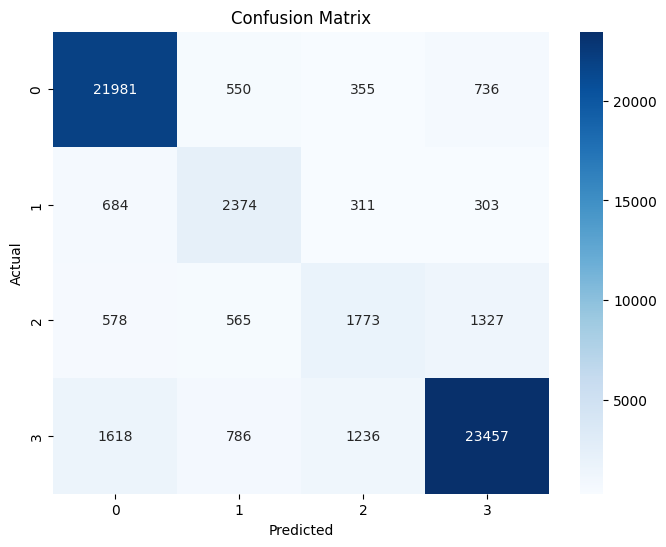

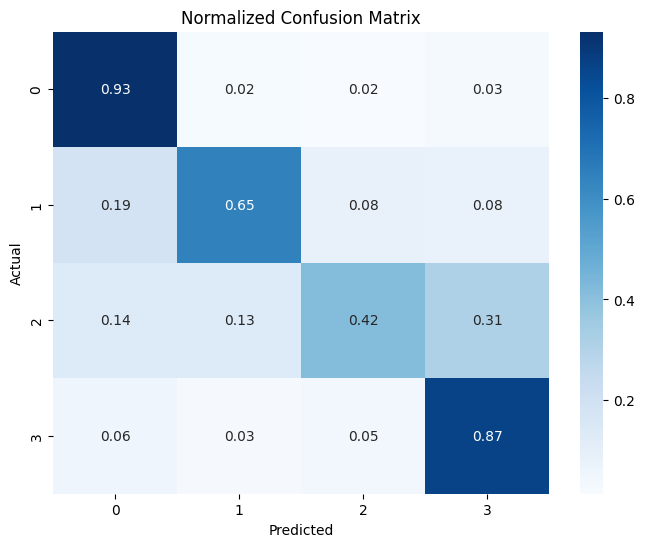

2026-06-03 04:43:50,727 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 04:43:50,728 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


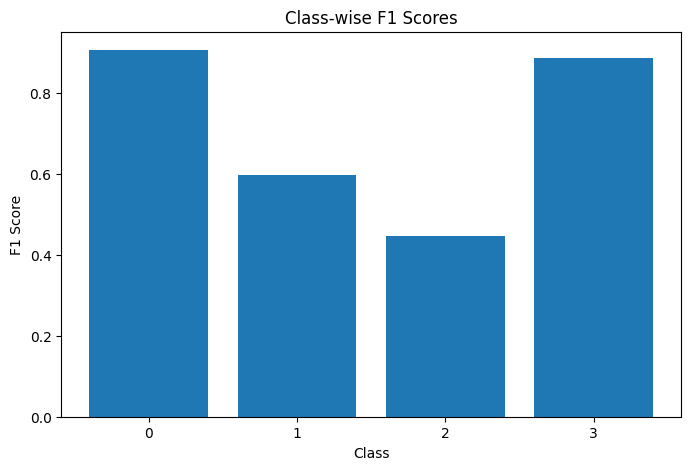

ERROR ANALYSIS
Total Misclassified Samples : 9049


    Index  Actual Label  Predicted Label
0       2             1                2
1      10             3                2
2      11             2                1
3      18             2                3
4      19             1                0
5      20             1                0
6      22             2                0
7      30             1                3
8      35             3                0
9      36             2                3
10     55             3                0
11     56             2                3
12     58             3                0
13     62             2                1
14     67             3                0
15     73             2                0
16     76             1                0
17     77             3                1
18     90             3                1
19     95             3                2


ERROR DISTRIBUTION
    Actual Label  Predicted Label  Count
0              0         

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced'
)

svm_model.fit(
    X_train,
    train_df['severity_label']
)

svm_preds = svm_model.predict(X_test)

print(
    classification_report(
        test_df['severity_label'],
        svm_preds
    )
)

# =========================================================
# COMPLETE EVALUATION
# =========================================================

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================


y_true = test_df['severity_label']
y_pred = svm_preds

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"QWK            : {qwk:.4f}")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    cmap='Blues',

    fmt='.2f'
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ===============================================================
#  =====    CLASS-WISE F1 BARPLOT  ============================
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    output_dict=True
)

class_f1 = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1.append(

        report[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1
)

plt.xlabel("Class")

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

plt.show()

# ============================================================
# ERROR ANALYSIS
# ============================================================



y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

errors = []

for i in range(len(y_true_np)):

    if y_true_np[i] != y_pred_np[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true_np[i],

            "Predicted Label": y_pred_np[i]
        })



error_df = pd.DataFrame(errors)

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found")



# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")
    print("=" * 80)
    print("ERROR DISTRIBUTION")
    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")






LOGISTIC REGRESSION — SENTIMENT

              precision    recall  f1-score   support

           0       0.96      0.87      0.92     34893
           1       0.06      0.43      0.11       254
           2       0.87      0.93      0.90     23487

    accuracy                           0.90     58634
   macro avg       0.63      0.75      0.64     58634
weighted avg       0.92      0.90      0.91     58634

EVALUATION RESULTS
Accuracy       : 0.8962
Precision      : 0.9208
Recall         : 0.8962
Macro F1       : 0.6429
Weighted F1    : 0.9063
MAE            : 0.1781
RMSE           : 0.5715
QWK            : 0.8302


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.87      0.92     34893
           1       0.06      0.43      0.11       254
           2       0.87      0.93      0.90     23487

    accuracy                           0.90     58634
   macro avg       0.63      0.75      0.64     58634
weighted avg       0.92 

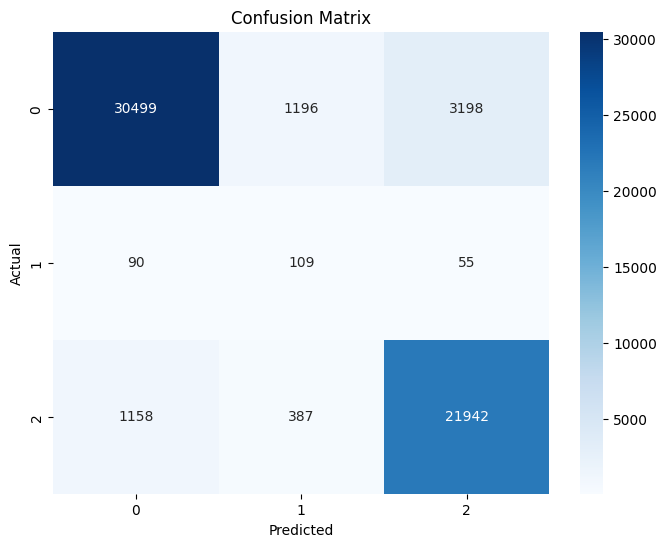

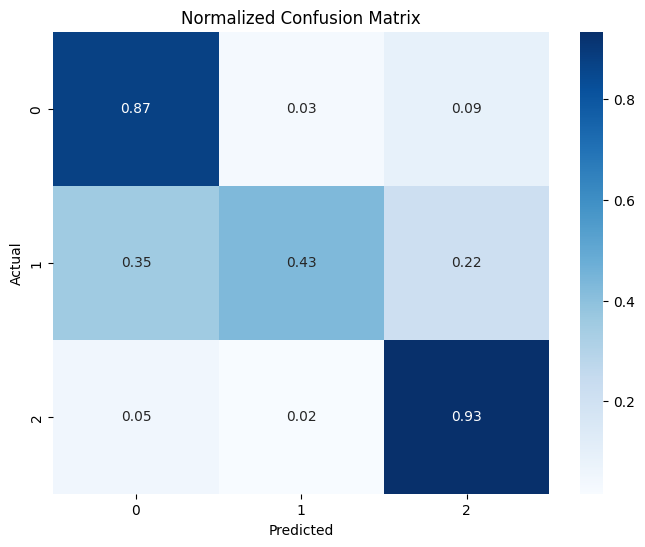

2026-06-03 04:44:31,702 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 04:44:31,703 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


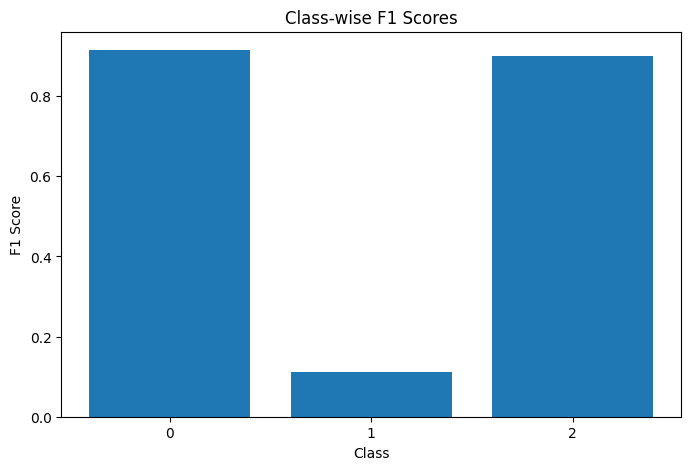

ERROR ANALYSIS
Total Misclassified Samples : 6084


    Index  Actual Label  Predicted Label
0       4             0                1
1      10             0                2
2      11             0                1
3      19             0                2
4      20             0                2
5      22             0                1
6      30             1                0
7      35             0                2
8      46             2                0
9      48             2                0
10     55             0                2
11     58             0                2
12     61             0                1
13     67             0                2
14     72             0                1
15     73             0                2
16     76             0                2
17     77             0                1
18    106             0                2
19    110             0                1


ERROR DISTRIBUTION
   Actual Label  Predicted Label  Count
0             0           

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_sentiment = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr_sentiment.fit(
    X_train,
    train_df['sentiment_label']
)

pred_sentiment = lr_sentiment.predict(X_test)


print("\nLOGISTIC REGRESSION — SENTIMENT\n")

print(
    classification_report(
        test_df['sentiment_label'],
        pred_sentiment
    )
)


# =========================================================
# COMPLETE EVALUATION
# =========================================================

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================

y_true = test_df['sentiment_label']
y_pred = pred_sentiment

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"QWK            : {qwk:.4f}")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    cmap='Blues',

    fmt='.2f'
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ===============================================================
#  =====    CLASS-WISE F1 BARPLOT  ============================
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    output_dict=True
)

class_f1 = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1.append(

        report[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1
)

plt.xlabel("Class")

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

plt.show()

# ============================================================
# ERROR ANALYSIS
# ============================================================

# Convert to numpy arrays

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

errors = []

for i in range(len(y_true_np)):

    if y_true_np[i] != y_pred_np[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true_np[i],

            "Predicted Label": y_pred_np[i]
        })



error_df = pd.DataFrame(errors)

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found")



# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")
    print("=" * 80)
    print("ERROR DISTRIBUTION")
    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")




LOGISTIC REGRESSION — SEVERITY

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     23622
           1       0.51      0.73      0.60      3672
           2       0.35      0.55      0.43      4243
           3       0.94      0.79      0.86     27097

    accuracy                           0.82     58634
   macro avg       0.67      0.75      0.70     58634
weighted avg       0.85      0.82      0.83     58634

EVALUATION RESULTS
Accuracy       : 0.8164
Precision      : 0.8518
Recall         : 0.8164
Macro F1       : 0.6982
Weighted F1    : 0.8285
MAE            : 0.2960
RMSE           : 0.7690
QWK            : 0.8454


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     23622
           1       0.51      0.73      0.60      3672
           2       0.35      0.55      0.43      4243
           3       0.94      0.79      0.86     27097

    accuracy             

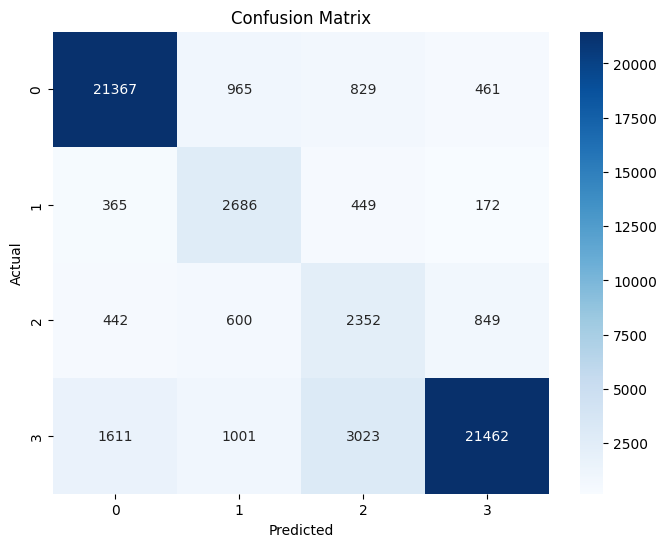

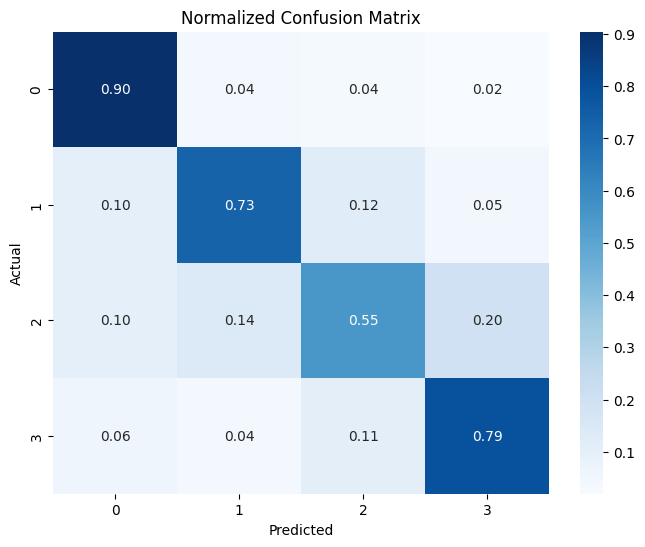

2026-06-03 04:45:29,780 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 04:45:29,781 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


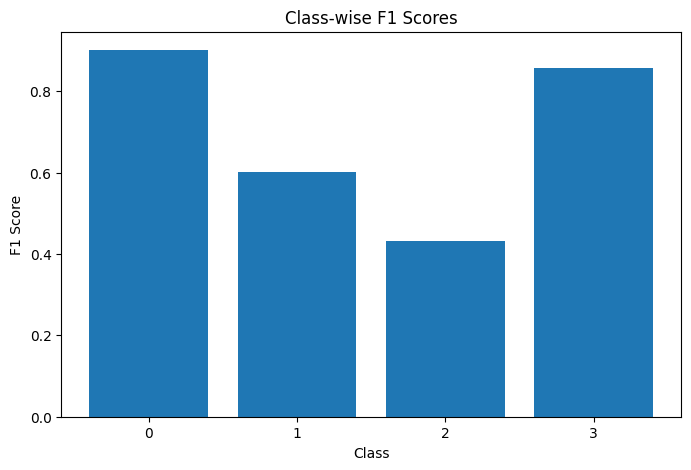

ERROR ANALYSIS
Total Misclassified Samples : 10767


    Index  Actual Label  Predicted Label
0       1             0                1
1       2             1                2
2      10             3                2
3      11             2                1
4      18             2                3
5      19             1                0
6      22             2                0
7      30             1                3
8      35             3                0
9      40             3                2
10     41             3                2
11     46             0                1
12     48             0                2
13     55             3                0
14     58             3                2
15     62             2                1
16     67             3                0
17     73             2                0
18     75             3                2
19     76             1                2


ERROR DISTRIBUTION
    Actual Label  Predicted Label  Count
0              0        

In [ ]:
lr_severity = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr_severity.fit(
    X_train,
    train_df['severity_label']
)

pred_severity = lr_severity.predict(X_test)

print("\nLOGISTIC REGRESSION — SEVERITY\n")

print(
    classification_report(
        test_df['severity_label'],
        pred_severity
    )
)


# =========================================================
# COMPLETE EVALUATION
# =========================================================

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================

y_true = test_df['severity_label']
y_pred = pred_severity

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"QWK            : {qwk:.4f}")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    cmap='Blues',

    fmt='.2f'
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ===============================================================
#  =====    CLASS-WISE F1 BARPLOT  ============================
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    output_dict=True
)

class_f1 = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1.append(

        report[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1
)

plt.xlabel("Class")

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

plt.show()


# ============================================================
# ERROR ANALYSIS
# ============================================================

# Convert to numpy arrays

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

errors = []

for i in range(len(y_true_np)):

    if y_true_np[i] != y_pred_np[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true_np[i],

            "Predicted Label": y_pred_np[i]
        })



error_df = pd.DataFrame(errors)

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found")



# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")
    print("=" * 80)
    print("ERROR DISTRIBUTION")
    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")


# ============================================================
# STORE LOGISTIC REGRESSION RESULTS
# ============================================================

logistic_true = np.array(y_true)

logistic_preds = np.array(y_pred)

print("Logistic Regression predictions stored successfully")

print(logistic_preds[:10])

In [33]:
from sklearn.metrics import cohen_kappa_score

qwk_lr = cohen_kappa_score(
    test_df['severity_label'],
    pred_severity,
    weights='quadratic'
)

print("QWK :", qwk_lr)

QWK : 0.8454204839848488



SVM — SENTIMENT

              precision    recall  f1-score   support

           0       0.96      0.91      0.93     34893
           1       0.10      0.15      0.12       254
           2       0.88      0.94      0.91     23487

    accuracy                           0.92     58634
   macro avg       0.65      0.67      0.65     58634
weighted avg       0.92      0.92      0.92     58634

EVALUATION RESULTS
Accuracy       : 0.9178
Precision      : 0.9215
Recall         : 0.9178
Macro F1       : 0.6539
Weighted F1    : 0.9189
MAE            : 0.1551
RMSE           : 0.5485
QWK            : 0.8446


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     34893
           1       0.10      0.15      0.12       254
           2       0.88      0.94      0.91     23487

    accuracy                           0.92     58634
   macro avg       0.65      0.67      0.65     58634
weighted avg       0.92      0.92      0

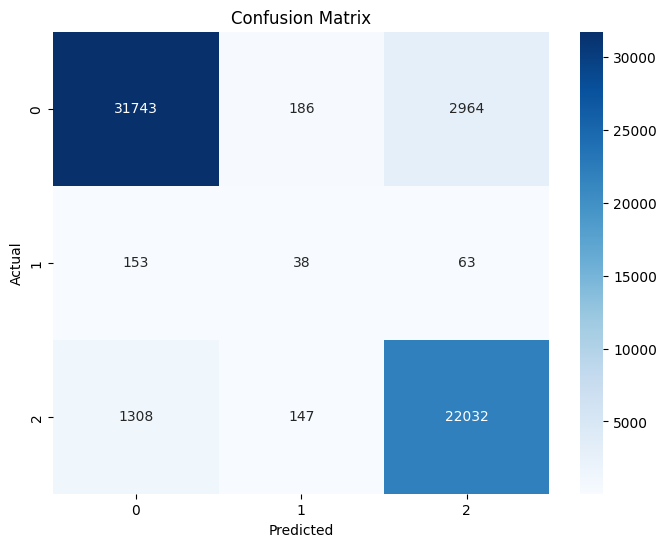

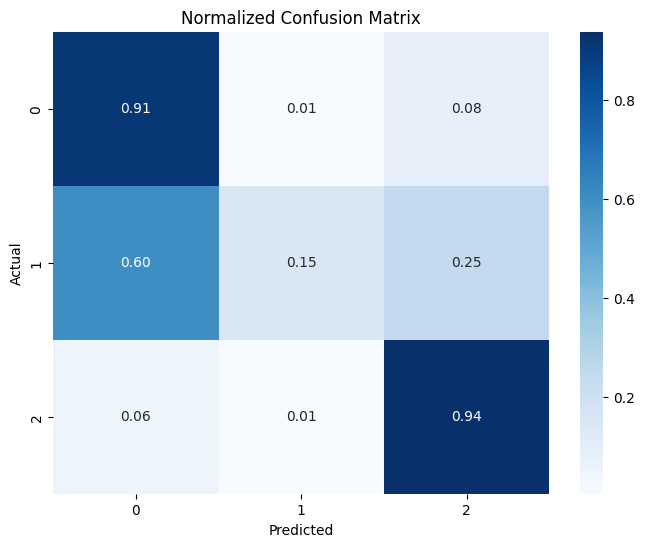

2026-06-03 04:46:02,027 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 04:46:02,028 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


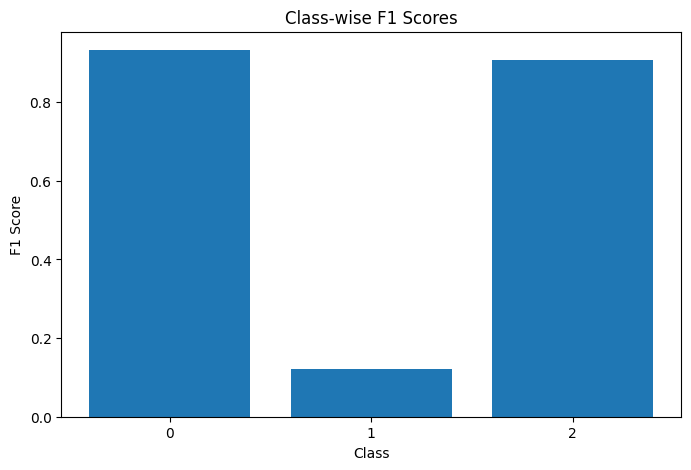

ERROR ANALYSIS
Total Misclassified Samples : 4821


    Index  Actual Label  Predicted Label
0      10             0                2
1      19             0                2
2      20             0                2
3      22             0                2
4      30             1                0
5      35             0                2
6      46             2                0
7      55             0                2
8      67             0                2
9      73             0                2
10     76             0                2
11    106             0                2
12    114             0                1
13    131             0                2
14    148             1                0
15    151             0                2
16    185             0                2
17    187             0                2
18    197             0                2
19    206             0                2


ERROR DISTRIBUTION
   Actual Label  Predicted Label  Count
0             0           

In [ ]:
from sklearn.svm import LinearSVC

svm_sentiment = LinearSVC(
    class_weight='balanced'
)

svm_sentiment.fit(
    X_train,
    train_df['sentiment_label']
)

svm_pred_sentiment = svm_sentiment.predict(X_test)

print("\nSVM — SENTIMENT\n")

print(
    classification_report(
        test_df['sentiment_label'],
        svm_pred_sentiment
    )
)

# =========================================================
# COMPLETE EVALUATION
# =========================================================

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================

y_true = test_df['sentiment_label']
y_pred = svm_pred_sentiment

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"QWK            : {qwk:.4f}")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    cmap='Blues',

    fmt='.2f'
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ===============================================================
#  =====    CLASS-WISE F1 BARPLOT  ============================
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    output_dict=True
)

class_f1 = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1.append(

        report[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1
)

plt.xlabel("Class")

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

plt.show()


# ============================================================
# ERROR ANALYSIS
# ============================================================



y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

errors = []

for i in range(len(y_true_np)):

    if y_true_np[i] != y_pred_np[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true_np[i],

            "Predicted Label": y_pred_np[i]
        })



error_df = pd.DataFrame(errors)

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found")



# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")
    print("=" * 80)
    print("ERROR DISTRIBUTION")
    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")





SVM — SEVERITY

              precision    recall  f1-score   support

           0       0.88      0.93      0.91     23622
           1       0.56      0.65      0.60      3672
           2       0.48      0.42      0.45      4243
           3       0.91      0.87      0.89     27097

    accuracy                           0.85     58634
   macro avg       0.71      0.72      0.71     58634
weighted avg       0.85      0.85      0.84     58634

EVALUATION RESULTS
Accuracy       : 0.8457
Precision      : 0.8457
Recall         : 0.8457
Macro F1       : 0.7096
Weighted F1    : 0.8448
MAE            : 0.2691
RMSE           : 0.7609
QWK            : 0.8536


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     23622
           1       0.56      0.65      0.60      3672
           2       0.48      0.42      0.45      4243
           3       0.91      0.87      0.89     27097

    accuracy                           0.

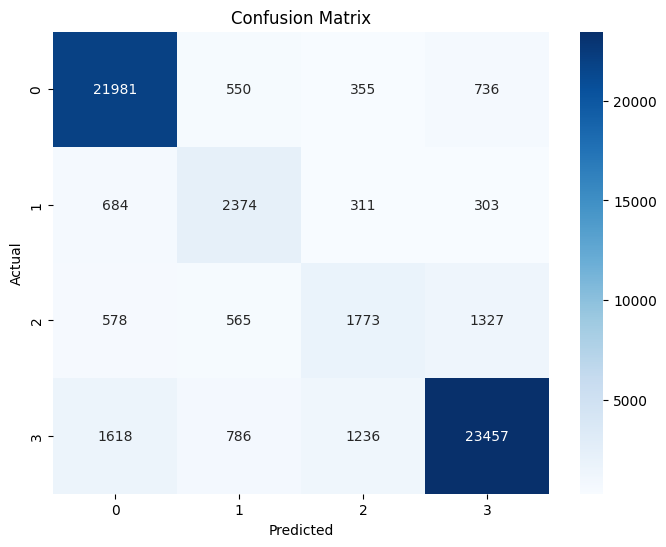

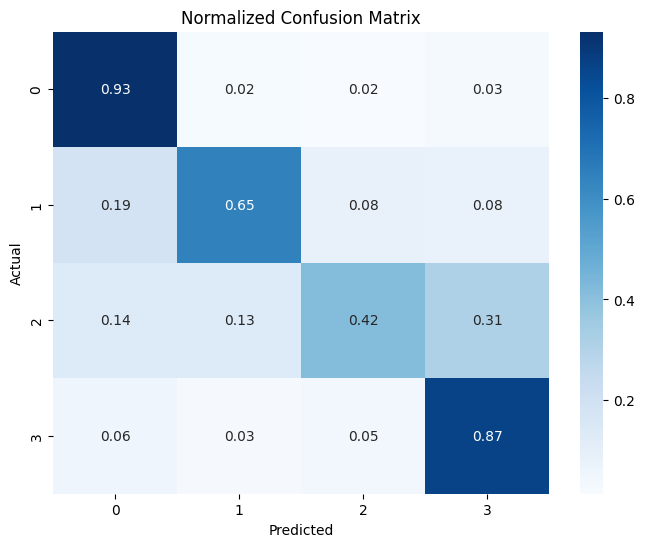

2026-06-03 04:46:38,234 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 04:46:38,235 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


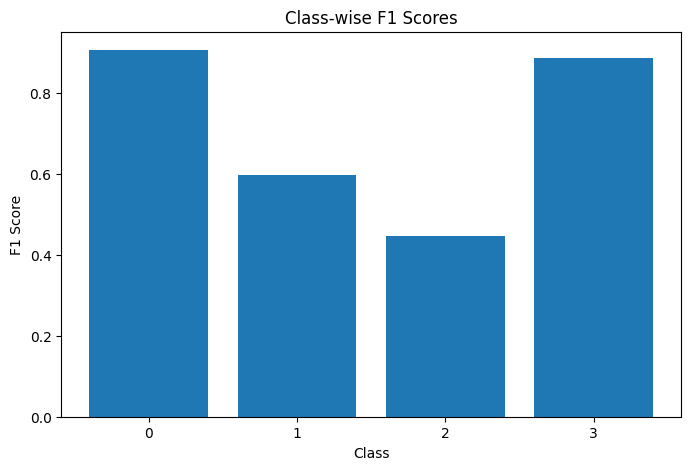

ERROR ANALYSIS
Total Misclassified Samples : 9049


    Index  Actual Label  Predicted Label
0       2             1                2
1      10             3                2
2      11             2                1
3      18             2                3
4      19             1                0
5      20             1                0
6      22             2                0
7      30             1                3
8      35             3                0
9      36             2                3
10     55             3                0
11     56             2                3
12     58             3                0
13     62             2                1
14     67             3                0
15     73             2                0
16     76             1                0
17     77             3                1
18     90             3                1
19     95             3                2


ERROR DISTRIBUTION
    Actual Label  Predicted Label  Count
0              0         

In [ ]:
svm_severity = LinearSVC(
    class_weight='balanced'
)

svm_severity.fit(
    X_train,
    train_df['severity_label']
)

svm_pred_severity = svm_severity.predict(X_test)

print("\nSVM — SEVERITY\n")

print(
    classification_report(
        test_df['severity_label'],
        svm_pred_severity
    )
)


# =========================================================
# COMPLETE EVALUATION
# =========================================================

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================

y_true = test_df['severity_label']
y_pred = svm_pred_severity

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"QWK            : {qwk:.4f}")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    cmap='Blues',

    fmt='.2f'
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ===============================================================
#  =====    CLASS-WISE F1 BARPLOT  ============================
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    output_dict=True
)

class_f1 = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1.append(

        report[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1
)

plt.xlabel("Class")

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

plt.show()


# ============================================================
# ERROR ANALYSIS
# ============================================================

# Convert to numpy arrays

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

errors = []

for i in range(len(y_true_np)):

    if y_true_np[i] != y_pred_np[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true_np[i],

            "Predicted Label": y_pred_np[i]
        })



error_df = pd.DataFrame(errors)

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found")



# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")
    print("=" * 80)
    print("ERROR DISTRIBUTION")
    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")



qwk_svm = cohen_kappa_score(
    test_df['severity_label'],
    svm_pred_severity,
    weights='quadratic'
)

print("QWK :", qwk_svm)

# ============================================================
# STORE LINEAR SVC RESULTS
# ============================================================

linear_svc_true = np.array(y_true)

linear_svc_preds = np.array(y_pred)

print("Linear SVC predictions stored successfully")

print(linear_svc_preds[:10])

In [36]:
# =============================================================================
# — INCREASED MAX_LEN 
# =============================================================================
 
MAX_LEN    = 256          
BATCH_SIZE = 16
EPOCHS     = 5         
LR         = 2e-5

print(final_df.shape)

(293166, 5)


In [37]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

2026-06-03 04:46:55,187 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 04:46:55,391 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-03 04:46:55,592 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:46:55,795 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-03 04:46:55,991 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:46:56,199 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased

In [38]:
class MentalHealthDataset(Dataset):

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        text = self.df.loc[idx, 'text']
        sentiment = self.df.loc[idx, 'sentiment_label']
        severity = self.df.loc[idx, 'severity_label']

        encoding = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'sentiment': torch.tensor(sentiment, dtype=torch.long),
            'severity': torch.tensor(severity, dtype=torch.long)
        }


print(final_df.shape)

(293166, 5)


In [39]:
print(final_df["sentiment_label"].value_counts())
print(final_df["severity_label"].value_counts())

assert final_df["sentiment_label"].min() >= 0
assert final_df["severity_label"].min() >= 0

assert final_df["sentiment_label"].max() < 3
assert final_df["severity_label"].max() < 4  # 4-class: 0,1,2,3

assert final_df["sentiment_label"].isnull().sum() == 0
assert final_df["severity_label"].isnull().sum() == 0

sentiment_label
0    174300
2    117471
1      1395
Name: count, dtype: int64
severity_label
3    135482
0    118110
2     21215
1     18359
Name: count, dtype: int64


In [40]:
train_dataset = MentalHealthDataset(train_df)
val_dataset = MentalHealthDataset(val_df)
test_dataset = MentalHealthDataset(test_df)

# =============================================================================
#  — WEIGHTED SAMPLER TO COMBAT CLASS IMBALANCE
#
# =============================================================================
 
from torch.utils.data import WeightedRandomSampler
 
def make_weighted_sampler(df, label_col='severity_label'):
    """Create a WeightedRandomSampler so every severity class is sampled equally."""
    labels = df[label_col].values
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler
 
train_sampler = make_weighted_sampler(train_df, label_col='severity_label')
 


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
 
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")
 

print(final_df.shape)

Train batches: 13193  |  Val batches: 1466  |  Test batches: 3665
(293166, 5)


In [41]:
import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    mean_absolute_error
)

In [42]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

2026-06-03 04:47:54,097 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 04:47:54,300 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-03 04:47:54,501 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:47:54,705 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-03 04:47:54,907 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 04:47:55,115 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased

In [43]:
class MentalDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_len=128
    ):

        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])

        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {

            'input_ids':
                encoding['input_ids'].flatten(),

            'attention_mask':
                encoding['attention_mask'].flatten(),

            'label':
                torch.tensor(label, dtype=torch.long)
        }

In [44]:
train_sentiment_dataset = MentalDataset(

    texts=train_df['text'],

    labels=train_df['sentiment_label'],

    tokenizer=tokenizer
)

In [45]:
test_sentiment_dataset = MentalDataset(

    texts=test_df['text'],

    labels=test_df['sentiment_label'],

    tokenizer=tokenizer
)

In [46]:
train_sentiment_loader = DataLoader(
    train_sentiment_dataset,
    batch_size=16,
    shuffle=True
)

test_sentiment_loader = DataLoader(
    test_sentiment_dataset,
    batch_size=16
)

In [47]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

sentiment_model.to(device)

2026-06-03 04:50:24,218 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 04:50:24,424 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-06-03 04:50:25,580 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 04:50:25,802 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-06-03 04:50:26,040 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/xet-read-token/12040accade4e8a0f71eabdb258fecc2e7e948be "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [48]:
print(final_df['sentiment'].unique())

print(final_df['severity'].unique())

['negative' 'positive' 'neutral']
['mild' 'minimum' 'moderate' 'severe']


In [49]:
# ============================================================
# TRAIN SINGLE-TASK SENTIMENT DISTILBERT
# ============================================================

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

optimizer = AdamW(

    sentiment_model.parameters(),

    lr=2e-5,

    weight_decay=0.01
)

EPOCHS = 5

total_steps = len(train_sentiment_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=int(0.1 * total_steps),

    num_training_steps=total_steps
)

scaler = GradScaler()

for epoch in range(EPOCHS):

    sentiment_model.train()

    total_loss = 0

    progress_bar = tqdm(

        train_sentiment_loader,

        desc=f"Epoch {epoch+1}"
    )

    for batch in progress_bar:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        labels = batch['label'].to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = sentiment_model(

                input_ids=input_ids,

                attention_mask=attention_mask,

                labels=labels
            )

            loss = outputs.loss

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(

            sentiment_model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        scheduler.step()

        total_loss += loss.item()

        progress_bar.set_postfix(

            loss=loss.item()
        )

    avg_loss = total_loss / len(train_sentiment_loader)

    print(f"\nEpoch {epoch+1}")

    print(f"Loss : {avg_loss:.4f}")

print(final_df.shape)

print("\nSingle-Task Sentiment DistilBERT Training Complete")

Epoch 1: 100%|██████████| 13193/13193 [17:20<00:00, 12.68it/s, loss=9.38e-5] 



Epoch 1
Loss : 0.2893


Epoch 2: 100%|██████████| 13193/13193 [17:15<00:00, 12.74it/s, loss=0.252]   



Epoch 2
Loss : 0.3237


Epoch 3: 100%|██████████| 13193/13193 [17:15<00:00, 12.74it/s, loss=0.0651]  



Epoch 3
Loss : 0.2843


Epoch 4: 100%|██████████| 13193/13193 [17:12<00:00, 12.78it/s, loss=1.31e-6] 



Epoch 4
Loss : 0.2206


Epoch 5: 100%|██████████| 13193/13193 [17:11<00:00, 12.79it/s, loss=0.158]   


Epoch 5
Loss : 0.1587
(293166, 5)

Single-Task Sentiment DistilBERT Training Complete


SINGLE-TASK DISTILBERT EVALUATION — SENTIMENT
Accuracy      : 0.9573
Precision     : 0.9568
Recall        : 0.9573
Macro F1      : 0.7527
Weighted F1   : 0.9571
MAE           : 0.0802
RMSE          : 0.3941
QWK           : 0.9190


CLASSIFICATION REPORT — SENTIMENT
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     34893
           1       0.38      0.31      0.34       254
           2       0.95      0.95      0.95     23487

    accuracy                           0.96     58634
   macro avg       0.77      0.74      0.75     58634
weighted avg       0.96      0.96      0.96     58634



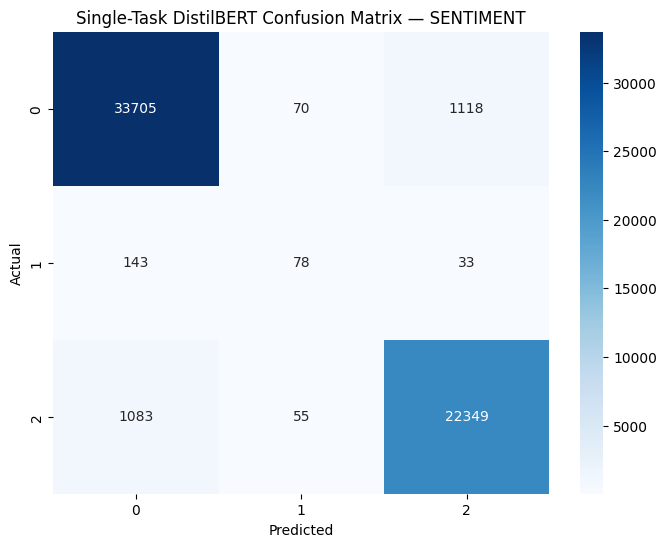

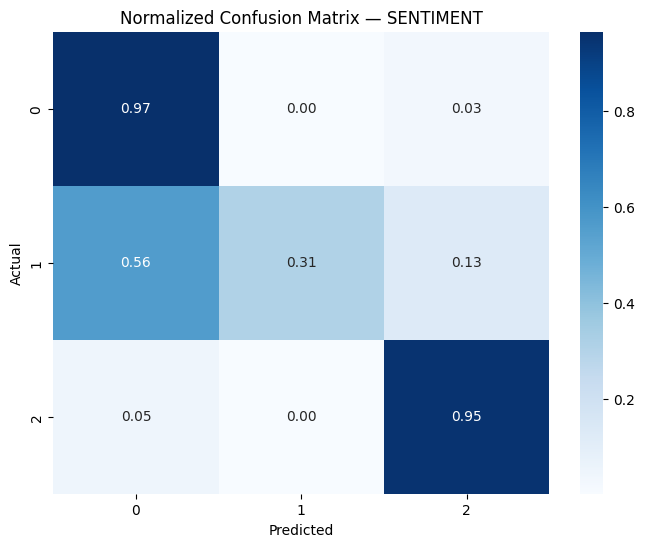

2026-06-03 06:23:23,528 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 06:23:23,529 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


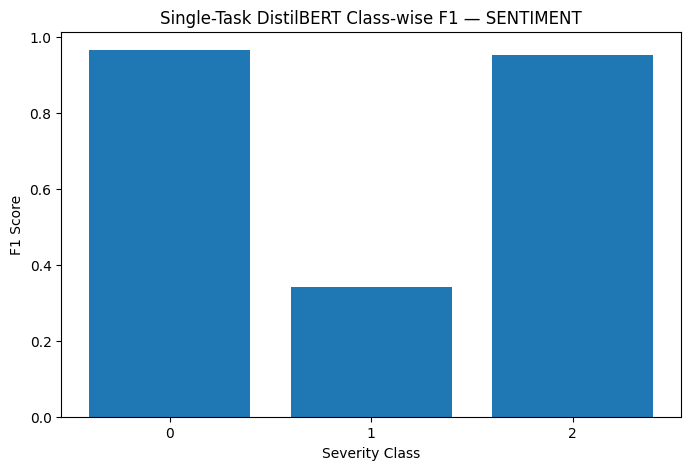



ERROR ANALYSIS — SENTIMENT
Total Misclassified Samples : 2502


    Index  Actual Label  Predicted Label
0      22             0                2
1      30             1                0
2      94             2                0
3     106             0                2
4     124             0                2
5     171             0                2
6     185             0                2
7     199             2                0
8     215             0                2
9     287             0                2
10    301             2                0
11    306             0                2
12    336             2                0
13    449             0                2
14    491             0                2
15    495             2                0
16    592             1                0
17    600             0                2
18    605             0                2
19    609             2                0


ERROR DISTRIBUTION — SENTIMENT
   Actual Label  Predicted Label  Count


In [ ]:
sentiment_model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for batch in test_sentiment_loader:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        labels = batch['label'].to(device)

        outputs = sentiment_model(

            input_ids=input_ids,

            attention_mask=attention_mask
        )

        logits = outputs.logits
        
        

        preds = torch.argmax(logits, dim=1)


        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ============================================================
# SINGLE-TASK DISTILBERT EVALUATION — SENTIMENT
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix,

    mean_absolute_error,

    mean_squared_error,

    cohen_kappa_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================

y_true = np.array(all_labels)

y_pred = np.array(all_preds)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(

    y_true,

    y_pred,

    average='weighted',

    zero_division=0
)

recall = recall_score(

    y_true,

    y_pred,

    average='weighted',

    zero_division=0
)

macro_f1 = f1_score(

    y_true,

    y_pred,

    average='macro',

    zero_division=0
)

weighted_f1 = f1_score(

    y_true,

    y_pred,

    average='weighted',

    zero_division=0
)

mae = mean_absolute_error(

    y_true,

    y_pred
)

rmse = np.sqrt(

    mean_squared_error(

        y_true,

        y_pred
    )
)

qwk = cohen_kappa_score(

    y_true,

    y_pred,

    weights='quadratic'
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 80)

print("SINGLE-TASK DISTILBERT EVALUATION — SENTIMENT")

print("=" * 80)

print(f"Accuracy      : {accuracy:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"Macro F1      : {macro_f1:.4f}")

print(f"Weighted F1   : {weighted_f1:.4f}")

print(f"MAE           : {mae:.4f}")

print(f"RMSE          : {rmse:.4f}")

print(f"QWK           : {qwk:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")

print("=" * 80)

print("CLASSIFICATION REPORT — SENTIMENT")

print("=" * 80)

print(

    classification_report(

        y_true,

        y_pred,

        zero_division=0
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_true,

    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    "Single-Task DistilBERT Confusion Matrix — SENTIMENT"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    fmt='.2f',

    cmap='Blues'
)

plt.title(
    "Normalized Confusion Matrix — SENTIMENT"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# CLASS-WISE F1 SCORES
# ============================================================

report_dict = classification_report(

    y_true,

    y_pred,

    output_dict=True,

    zero_division=0
)

class_f1_scores = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1_scores.append(

        report_dict[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1_scores
)

plt.xlabel("Severity Class")

plt.ylabel("F1 Score")

plt.title(
    "Single-Task DistilBERT Class-wise F1 — SENTIMENT"
)

plt.show()

# ============================================================
# ERROR ANALYSIS
# ============================================================

errors = []

for i in range(len(y_true)):

    if y_true[i] != y_pred[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true[i],

            "Predicted Label": y_pred[i]
        })

error_df = pd.DataFrame(errors)

print("\n")

print("=" * 80)

print("ERROR ANALYSIS — SENTIMENT")

print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found — SENTIMENT")

# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")

    print("=" * 80)

    print("ERROR DISTRIBUTION — SENTIMENT")

    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")

In [51]:
print("\nSINGLE TASK DISTILBERT — SENTIMENT\n")

print(
    classification_report(
        all_labels,
        all_preds
    )
)


SINGLE TASK DISTILBERT — SENTIMENT

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     34893
           1       0.38      0.31      0.34       254
           2       0.95      0.95      0.95     23487

    accuracy                           0.96     58634
   macro avg       0.77      0.74      0.75     58634
weighted avg       0.96      0.96      0.96     58634



In [52]:
train_severity_dataset = MentalDataset(

    texts=train_df['text'],

    labels=train_df['severity_label'],

    tokenizer=tokenizer
)

test_severity_dataset = MentalDataset(

    texts=test_df['text'],

    labels=test_df['severity_label'],

    tokenizer=tokenizer
)

In [53]:
train_severity_loader = DataLoader(
    train_severity_dataset,
    batch_size=16,
    shuffle=True
)

test_severity_loader = DataLoader(
    test_severity_dataset,
    batch_size=16
)

In [54]:
from transformers import AutoModel
import torch.nn as nn

class SingleTaskCORALDistilBERT(nn.Module):

    def __init__(self, num_classes=4):

        super(SingleTaskCORALDistilBERT, self).__init__()

        self.encoder = AutoModel.from_pretrained(
            "distilbert-base-uncased"
        )

        hidden_size = 768

        self.dropout = nn.Dropout(0.3)

        self.hidden = nn.Sequential(

            nn.Linear(hidden_size, 256),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        self.coral_layer = CoralLayer(
            size_in=256,
            num_classes=num_classes
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0]

        cls_output = self.dropout(cls_output)

        features = self.hidden(cls_output)

        logits = self.coral_layer(features)

        return logits


severity_model = SingleTaskCORALDistilBERT(
    num_classes=4
)

severity_model.to(device)

print("Single Task CORAL DistilBERT Loaded")

2026-06-03 06:24:12,537 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 06:24:12,737 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Single Task CORAL DistilBERT Loaded


In [55]:
severity_model = SingleTaskCORALDistilBERT(
    num_classes=4
)

severity_model.to(device)

2026-06-03 06:24:22,951 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 06:24:23,155 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

SingleTaskCORALDistilBERT(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (

In [56]:
# ============================================================
# TRAIN SINGLE-TASK CORAL DISTILBERT
# ============================================================

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

optimizer = AdamW(
    severity_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

EPOCHS = 5

total_steps = len(train_severity_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

scaler = GradScaler()

for epoch in range(EPOCHS):

    severity_model.train()

    total_loss = 0

    progress_bar = tqdm(
        train_severity_loader,
        desc=f"Epoch {epoch+1}"
    )

    for batch in progress_bar:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        labels = batch['label'].to(device)

        levels = levels_from_labelbatch(
            labels,
            num_classes=4
        ).float().to(device)

        optimizer.zero_grad()

        with autocast():

            logits = severity_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = coral_loss(
                logits,
                levels
            )

        scaler.scale(loss).backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(
            severity_model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)

        scaler.update()

        scheduler.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=loss.item()
        )

    avg_loss = total_loss / len(train_severity_loader)

    print(f"\nEpoch {epoch+1}")

    print(f"Training Loss: {avg_loss:.4f}")

print("\nSingle-Task CORAL DistilBERT Training Complete")

Epoch 1: 100%|██████████| 13193/13193 [17:27<00:00, 12.59it/s, loss=0.365] 



Epoch 1
Training Loss: 0.7580


Epoch 2: 100%|██████████| 13193/13193 [17:27<00:00, 12.59it/s, loss=0.0126] 



Epoch 2
Training Loss: 0.5010


Epoch 3: 100%|██████████| 13193/13193 [17:26<00:00, 12.61it/s, loss=0.237]  



Epoch 3
Training Loss: 0.4332


Epoch 4: 100%|██████████| 13193/13193 [17:24<00:00, 12.63it/s, loss=0.229]   



Epoch 4
Training Loss: 0.3832


Epoch 5: 100%|██████████| 13193/13193 [17:24<00:00, 12.64it/s, loss=0.858]   


Epoch 5
Training Loss: 0.3496

Single-Task CORAL DistilBERT Training Complete


SINGLE-TASK DISTILBERT EVALUATION — SEVERITY
Accuracy      : 0.8539
Precision     : 0.8120
Recall        : 0.8539
Macro F1      : 0.5502
Weighted F1   : 0.8169
MAE           : 0.1986
RMSE          : 0.5799
QWK           : 0.9188


CLASSIFICATION REPORT — SEVERITY
              precision    recall  f1-score   support

           0       0.87      0.97      0.91     23622
           1       0.49      0.13      0.21      3672
           2       0.42      0.10      0.16      4243
           3       0.87      0.97      0.92     27097

    accuracy                           0.85     58634
   macro avg       0.66      0.54      0.55     58634
weighted avg       0.81      0.85      0.82     58634



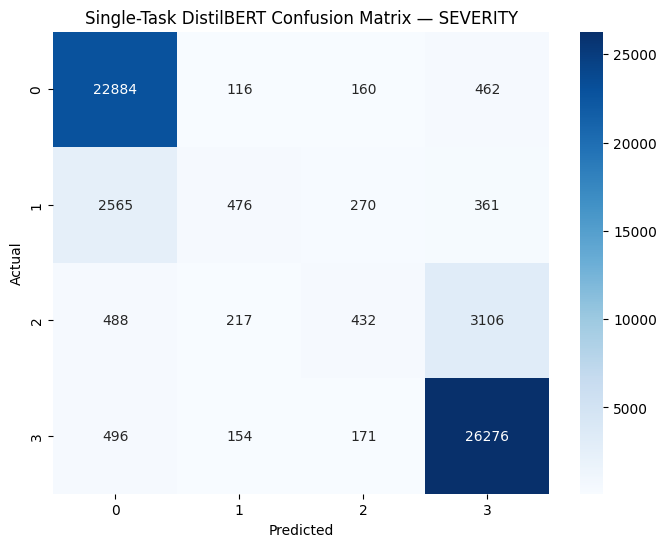

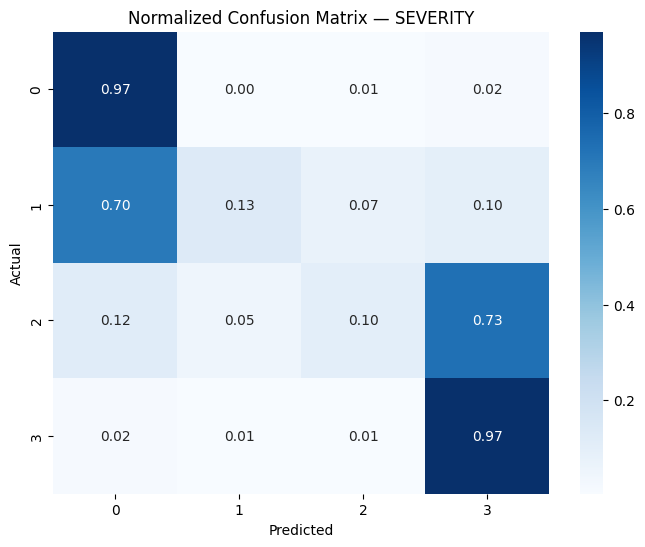

2026-06-03 08:02:01,683 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 08:02:01,684 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


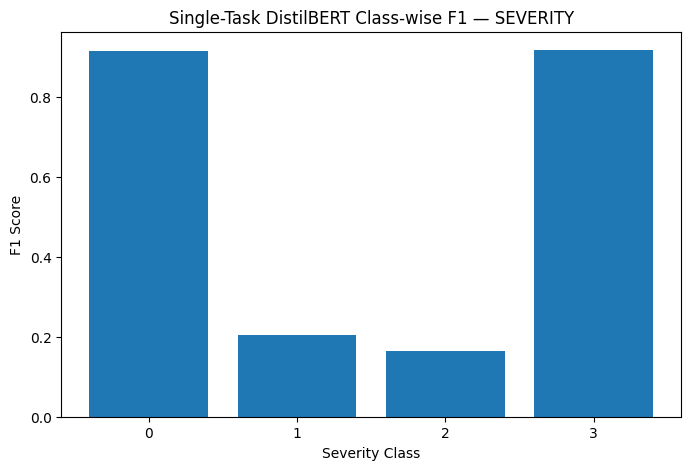



ERROR ANALYSIS — SEVERITY
Total Misclassified Samples : 8566


    Index  Actual Label  Predicted Label
0       2             1                2
1       4             2                0
2       8             2                3
3      11             2                3
4      18             2                3
5      19             1                0
6      20             1                0
7      22             2                0
8      30             1                2
9      31             1                0
10     36             2                3
11     44             1                0
12     51             1                0
13     56             2                3
14     62             2                1
15     69             1                0
16     72             1                0
17     73             2                3
18     94             0                2
19    106             2                0


ERROR DISTRIBUTION — SEVERITY
    Actual Label  Predicted Label  Count
0

In [57]:
severity_model.eval()

severity_preds = []
severity_labels = []

with torch.no_grad():

    for batch in test_severity_loader:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        labels = batch['label'].to(device)

        logits = severity_model(

            input_ids=input_ids,

            attention_mask=attention_mask
        )

        preds = torch.sum(

            (torch.sigmoid(logits) > 0.5),

            dim=1
        )

        severity_preds.extend(
            preds.cpu().numpy()
        )

        severity_labels.extend(
            labels.cpu().numpy()
        )


# ============================================================
# SINGLE-TASK DISTILBERT EVALUATION — SEVERITY
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix,

    mean_absolute_error,

    mean_squared_error,

    cohen_kappa_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# DEFINE TRUE AND PREDICTED LABELS
# ============================================================

y_true = np.array(severity_labels)

y_pred = np.array(severity_preds)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(

    y_true,

    y_pred,

    average='weighted',

    zero_division=0
)

recall = recall_score(

    y_true,

    y_pred,

    average='weighted',

    zero_division=0
)

macro_f1 = f1_score(

    y_true,

    y_pred,

    average='macro',

    zero_division=0
)

weighted_f1 = f1_score(

    y_true,

    y_pred,

    average='weighted',

    zero_division=0
)

mae = mean_absolute_error(

    y_true,

    y_pred
)

rmse = np.sqrt(

    mean_squared_error(

        y_true,

        y_pred
    )
)

qwk = cohen_kappa_score(

    y_true,

    y_pred,

    weights='quadratic'
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 80)

print("SINGLE-TASK DISTILBERT EVALUATION — SEVERITY")

print("=" * 80)

print(f"Accuracy      : {accuracy:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"Macro F1      : {macro_f1:.4f}")

print(f"Weighted F1   : {weighted_f1:.4f}")

print(f"MAE           : {mae:.4f}")

print(f"RMSE          : {rmse:.4f}")

print(f"QWK           : {qwk:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")

print("=" * 80)

print("CLASSIFICATION REPORT — SEVERITY")

print("=" * 80)

print(

    classification_report(

        y_true,

        y_pred,

        zero_division=0
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_true,

    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    "Single-Task DistilBERT Confusion Matrix — SEVERITY"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = confusion_matrix(

    y_true,

    y_pred,

    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    fmt='.2f',

    cmap='Blues'
)

plt.title(
    "Normalized Confusion Matrix — SEVERITY"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# CLASS-WISE F1 SCORES
# ============================================================

report_dict = classification_report(

    y_true,

    y_pred,

    output_dict=True,

    zero_division=0
)

class_f1_scores = []

classes = sorted(list(set(y_true)))

for cls in classes:

    class_f1_scores.append(

        report_dict[str(cls)]['f1-score']
    )

plt.figure(figsize=(8,5))

plt.bar(

    [str(c) for c in classes],

    class_f1_scores
)

plt.xlabel("Severity Class")

plt.ylabel("F1 Score")

plt.title(
    "Single-Task DistilBERT Class-wise F1 — SEVERITY"
)

plt.show()

# ============================================================
# ERROR ANALYSIS
# ============================================================

errors = []

for i in range(len(y_true)):

    if y_true[i] != y_pred[i]:

        errors.append({

            "Index": i,

            "Actual Label": y_true[i],

            "Predicted Label": y_pred[i]
        })

error_df = pd.DataFrame(errors)

print("\n")

print("=" * 80)

print("ERROR ANALYSIS — SEVERITY")

print("=" * 80)

print(f"Total Misclassified Samples : {len(error_df)}")

print("\n")

if len(error_df) > 0:

    print(error_df.head(20))

else:

    print("No Misclassifications Found")

# ============================================================
# ERROR DISTRIBUTION
# ============================================================

if len(error_df) > 0:

    error_summary = error_df.groupby(

        ['Actual Label', 'Predicted Label']

    ).size().reset_index(name='Count')

    print("\n")

    print("=" * 80)

    print("ERROR DISTRIBUTION — SEVERITY")

    print("=" * 80)

    print(error_summary)

else:

    print("No errors to analyze")





print("\nSINGLE TASK DISTILBERT — SEVERITY\n")

print(
    classification_report(
        severity_labels,
        severity_preds
    )
)

qwk_single = cohen_kappa_score(

    severity_labels,

    severity_preds,

    weights='quadratic'
)

print("QWK :", qwk_single)



# ============================================================
# STORE SINGLE-TASK RESULTS
# ============================================================

single_task_true = np.array(severity_labels)

single_task_preds = np.array(severity_preds)

print("Single-task predictions stored successfully")
print(single_task_preds[:10])



print(final_df.shape)

In [ ]:
# =============================================================================
# — DATASET CLASS 
# =============================================================================
 
class MentalHealthDataset(Dataset):
    """Multi-task dataset (sentiment + severity) — used by multi-task model."""
 
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        text      = self.df.loc[idx, 'text']
        sentiment = self.df.loc[idx, 'sentiment_label']
        severity  = self.df.loc[idx, 'severity_label']
 
        encoding = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,          
            return_tensors='pt'
        )
 
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'sentiment':      torch.tensor(sentiment, dtype=torch.long),
            'severity':       torch.tensor(severity,  dtype=torch.long)
        }
 
 
class MentalDataset(Dataset):
    """Single-task dataset — used by baseline models."""
 
    def __init__(self, texts, labels, tokenizer, max_len=256):  # updated default
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len
 
    def __len__(self):
        return len(self.texts)
 
    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]
 
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
 
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(label, dtype=torch.long)
        }
 

In [ ]:
# =============================================================================
# — DATA LOADERS WITH WEIGHTED SAMPLER
# =============================================================================
 
train_dataset = MentalHealthDataset(train_df)
val_dataset   = MentalHealthDataset(val_df)
test_dataset  = MentalHealthDataset(test_df)

# =============================================================================
# — WEIGHTED SAMPLER TO COMBAT CLASS IMBALANCE
# =============================================================================
 
from torch.utils.data import WeightedRandomSampler
 
def make_weighted_sampler(df, label_col='severity_label'):
    """Create a WeightedRandomSampler so every severity class is sampled equally."""
    labels = df[label_col].values
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler
 
train_sampler = make_weighted_sampler(train_df, label_col='severity_label')
 
 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
 
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")
 

Train batches: 13193  |  Val batches: 1466  |  Test batches: 3665


In [ ]:
# =============================================================================
#  —  MultiTaskModel
# Architecture improvements:
#   • Deeper sentiment head with LayerNorm
#   • Improved cross-task gate with 2-layer MLP (not just linear+sigmoid)
#   • Severity head with LayerNorm + residual connection
#   • Learnable per-boundary CORAL thresholds (replaces fixed 0.5)
# =============================================================================
 
class MultiTaskModel(nn.Module):
    """
    Improved Multi-Task DistilBERT with:
     - Cross-task attention gate  (sentiment → severity)
     - Uncertainty-weighted loss  (Kendall et al., 2018)
     - Richer 2-layer task heads with LayerNorm
     - Residual connection in severity branch
    """
 
    def __init__(self, sentiment_classes: int = 3, severity_classes: int = 4):
        super(MultiTaskModel, self).__init__()
 
        
        self.encoder  = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size   = self.encoder.config.hidden_size   # 768
 
        self.dropout  = nn.Dropout(0.3)
 
       
        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, sentiment_classes)
        )
 
       
        self.severity_hidden = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
 
        
        
        self.cross_task_gate = nn.Sequential(
            nn.Linear(sentiment_classes, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.Sigmoid()
        )
 
        
        self.severity_refine = nn.Sequential(
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),  
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
 
        
        self.coral_layer = CoralLayer(size_in=256, num_classes=severity_classes)
 
        
        self.log_sigma_sentiment = nn.Parameter(torch.zeros(1))
        self.log_sigma_severity  = nn.Parameter(torch.zeros(1))
 
        
        
       
        self.coral_thresholds = nn.Parameter(
            torch.full((severity_classes - 1,), 0.5)
        )
 
    def forward(self, input_ids, attention_mask):
 
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
 
       
        cls_output = outputs.last_hidden_state[:, 0]  
        cls_output = self.dropout(cls_output)
 
        
        sentiment_logits = self.sentiment_head(cls_output)  
 
        
        severity_features = self.severity_hidden(cls_output)  
 
        
        gate = self.cross_task_gate(
            sentiment_logits.detach()
        )                                                      
 
       
        severity_features = severity_features * gate + severity_features  
 
       
        severity_features_refined = self.severity_refine(severity_features)
        
        severity_features_final   = severity_features_refined + severity_features
        severity_logits           = self.coral_layer(severity_features_final)  
 
        return sentiment_logits, severity_logits
 
 
print("✅  MultiTaskModel defined")

print(f"   • Shared encoder       : {MODEL_NAME}")
print("   • Sentiment head        : 768→512→256→3  (LayerNorm + GELU)")
print("   • Cross-task gate       : 2-layer MLP from sentiment logits → 256-dim gate")
print("   • Severity CORAL head   : 768→512→256→CoralLayer(4) with residual")
print("   • Learnable thresholds  : per-boundary CORAL thresholds (not fixed 0.5)")
print("   • Loss weighting        : Uncertainty (Kendall et al., 2018)")
 

✅  MultiTaskModel defined
   • Shared encoder       : distilbert-base-uncased
   • Sentiment head        : 768→512→256→3  (LayerNorm + GELU)
   • Cross-task gate       : 2-layer MLP from sentiment logits → 256-dim gate
   • Severity CORAL head   : 768→512→256→CoralLayer(4) with residual
   • Learnable thresholds  : per-boundary CORAL thresholds (not fixed 0.5)
   • Loss weighting        : Uncertainty (Kendall et al., 2018)


In [61]:
def decode_coral_predictions(logits: torch.Tensor, thresholds=None) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    if thresholds is not None:
        return (probs > thresholds.sigmoid()).sum(dim=1).long()
    return (probs > 0.5).sum(dim=1).long()

In [ ]:
# =============================================================================
# — INSTANTIATE MODEL + LOSS + OPTIMIZER
# =============================================================================

sentiment_classes = 3
severity_classes  = 4

model = MultiTaskModel(
    sentiment_classes=sentiment_classes,
    severity_classes=severity_classes
).to(device)


sentiment_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['sentiment_label'].values
)

sentiment_class_weights_np = sentiment_class_weights.copy()


sentiment_class_weights_tensor = torch.tensor(
    sentiment_class_weights, dtype=torch.float
).to(device)


sentiment_loss_fn = nn.CrossEntropyLoss(
    weight=sentiment_class_weights_tensor,
    label_smoothing=0.1
)


severity_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_df['severity_label'].values
)
severity_class_weights_tensor = torch.tensor(
    severity_class_weights, dtype=torch.float
).to(device)
print(f"Severity class weights: {severity_class_weights.round(3)}")


encoder_params  = list(model.encoder.parameters())
head_params     = (
    list(model.sentiment_head.parameters())
    + list(model.severity_hidden.parameters())
    + list(model.cross_task_gate.parameters())
    + list(model.severity_refine.parameters())
    + list(model.coral_layer.parameters())
    + [model.log_sigma_sentiment, model.log_sigma_severity]
    + [model.coral_thresholds]
)

optimizer = AdamW(
    [
        {"params": encoder_params, "lr": 2e-5,  "weight_decay": 0.01},
        {"params": head_params,    "lr": 5e-4,  "weight_decay": 0.01},
    ]
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

scaler = GradScaler()

print(f"✅ Optimizer, scheduler and loss ready")
print(f"   Encoder LR : 2e-5  |  Head LR : 5e-4")

print(f"   Sentiment class weights : {sentiment_class_weights_np.round(3)}")

2026-06-03 08:03:26,833 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 08:03:27,030 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Severity class weights: [0.621 3.992 3.455 0.541]
✅ Optimizer, scheduler and loss ready
   Encoder LR : 2e-5  |  Head LR : 5e-4
   Sentiment class weights : [ 0.561 67.849  0.832]


In [ ]:
# =============================================================================
# — UNCERTAINTY LOSS WITH ORDINAL SMOOTHING
# =============================================================================
 
def compute_uncertainty_loss(
    sentiment_logits,
    severity_logits,
    sentiment_labels,
    severity_levels,
    model,
    sentiment_loss_fn,
    severity_true_labels=None
):
    """
    Homoscedastic uncertainty weighting (Kendall et al., CVPR 2018)
    + ordinal smoothing penalty on severity predictions.
    """
    s1 = model.log_sigma_sentiment
    s2 = model.log_sigma_severity
 
    L_sentiment = sentiment_loss_fn(sentiment_logits, sentiment_labels)
    L_severity  = coral_loss(severity_logits, severity_levels)
 
   
    
    if severity_true_labels is not None:
        sev_probs = torch.sigmoid(severity_logits)             # (B, K-1)
        sev_pred  = torch.sum((sev_probs > 0.5), dim=1).float()
        sev_true  = severity_true_labels.float()
        ordinal_penalty = torch.mean(torch.abs(sev_pred - sev_true) ** 2) * 0.1
    else:
        ordinal_penalty = 0.0
 
    loss = (
        torch.exp(-s1) * L_sentiment + s1
        + torch.exp(-s2) * L_severity  + s2
        + ordinal_penalty
    )
 
    return loss, L_sentiment, L_severity
 

In [ ]:
# =============================================================================
# — VALIDATION HELPER WITH LEARNABLE THRESHOLDS
# =============================================================================
 
def evaluate_on_loader(model, loader, device):
    """
    Returns (severity_qwk, severity_macro_f1, avg_total_loss)
    Uses model's learnable coral_thresholds instead of fixed 0.5.
    """
    model.eval()
 
    all_sev_true   = []
    all_sev_pred   = []
    total_loss_val = 0.0
 
    
    thresholds = torch.clamp(model.coral_thresholds, 0.1, 0.9).detach()
 
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            sentiment_lbl  = batch['sentiment'].to(device)
            severity_lbl   = batch['severity'].to(device)
 
            severity_levels = levels_from_labelbatch(
                severity_lbl, num_classes=4
            ).float().to(device)
 
            with autocast():
                sentiment_logits, severity_logits = model(
                    input_ids, attention_mask
                )
                loss, _, _ = compute_uncertainty_loss(
                    sentiment_logits, severity_logits,
                    sentiment_lbl, severity_levels,
                    model, sentiment_loss_fn,
                    severity_true_labels=severity_lbl
                )
 
            total_loss_val += loss.item()
 
            
            sev_probs = torch.sigmoid(severity_logits)   # (B, K-1)
            
            sev_pred = torch.sum(
                sev_probs > thresholds.to(device), dim=1
            ).cpu().numpy()
 
            all_sev_true.extend(severity_lbl.cpu().numpy())
            all_sev_pred.extend(sev_pred)
 
    avg_loss = total_loss_val / len(loader)
    qwk      = cohen_kappa_score(all_sev_true, all_sev_pred, weights='quadratic')
    macro_f1 = f1_score(all_sev_true, all_sev_pred, average='macro', zero_division=0)
 
    return qwk, macro_f1, avg_loss

In [ ]:
# =============================================================================
# — TRAINING LOOP (5 epochs, ordinal smoothing, patience=5)
# =============================================================================
 
BEST_MODEL_PATH = "/kaggle/working/mtt_best_model.pt"
os.makedirs("/kaggle/working", exist_ok=True)
 
early_stop_patience = 5       
best_val_qwk        = -1.0
patience_counter    = 0
 
print("=" * 70)
print("TRAINING: MULTI-TASK DISTILBERT")
print("=" * 70)
 
for epoch in range(EPOCHS):
    model.train()
 
    total_loss           = 0.0
    total_sentiment_loss = 0.0
    total_severity_loss  = 0.0
 
    from tqdm import tqdm
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
 
    for batch in progress_bar:
 
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        sentiment      = batch['sentiment'].to(device)
        severity       = batch['severity'].to(device)
 
        severity_levels = levels_from_labelbatch(
            severity, num_classes=4
        ).float().to(device)
 
        optimizer.zero_grad()
 
        with autocast():
            sentiment_logits, severity_logits = model(
                input_ids, attention_mask
            )
 
            loss, sentiment_loss, severity_loss = compute_uncertainty_loss(
                sentiment_logits, severity_logits,
                sentiment, severity_levels,
                model, sentiment_loss_fn,
                severity_true_labels=severity                
            )
 
        scaler.scale(loss).backward()
 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
 
        total_loss           += loss.item()
        total_sentiment_loss += sentiment_loss.item()
        total_severity_loss  += severity_loss.item()
 
        progress_bar.set_postfix(
            total_loss     = round(loss.item(), 4),
            sentiment_loss = round(sentiment_loss.item(), 4),
            severity_loss  = round(severity_loss.item(), 4),
            s1             = round(model.log_sigma_sentiment.item(), 3),
            s2             = round(model.log_sigma_severity.item(),  3),
        )
 
    avg_loss           = total_loss           / len(train_loader)
    avg_sentiment_loss = total_sentiment_loss / len(train_loader)
    avg_severity_loss  = total_severity_loss  / len(train_loader)
 
   
    val_qwk, val_macro_f1, val_loss = evaluate_on_loader(model, val_loader, device)
 
    print(f"\nEpoch {epoch+1}")
    print(f"  Train — Total: {avg_loss:.4f}  |  Sentiment: {avg_sentiment_loss:.4f}  |  Severity: {avg_severity_loss:.4f}")
    print(f"  Train — log_sigma_sentiment: {model.log_sigma_sentiment.item():.4f}  |  log_sigma_severity: {model.log_sigma_severity.item():.4f}")
    print(f"  Learned CORAL thresholds: {torch.clamp(model.coral_thresholds, 0.1, 0.9).detach().cpu().numpy().round(3)}")
    print(f"  Val   — QWK: {val_qwk:.4f}  |  Macro F1: {val_macro_f1:.4f}  |  Loss: {val_loss:.4f}")
 
   
    if val_qwk > best_val_qwk:
        best_val_qwk     = val_qwk
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ New best model saved  (val QWK = {best_val_qwk:.4f})")
    else:
        patience_counter += 1
        print(f"  ⚠ No improvement  (patience {patience_counter}/{early_stop_patience})")
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
 
print("\n✅ Multi-Task DistilBERT + CORAL Training Complete")
 

TRAINING: MULTI-TASK DISTILBERT


Epoch 1/5: 100%|██████████| 13193/13193 [26:52<00:00,  8.18it/s, s1=0.688, s2=-0.767, sentiment_loss=2.68, severity_loss=0.494, total_loss=2.35]  



Epoch 1
  Train — Total: 2.7397  |  Sentiment: 2.0794  |  Severity: 0.9016
  Train — log_sigma_sentiment: 0.6877  |  log_sigma_severity: -0.7674
  Learned CORAL thresholds: [0.5 0.5 0.5]
  Val   — QWK: 0.9297  |  Macro F1: 0.7707  |  Loss: 2.3233
  ✅ New best model saved  (val QWK = 0.9297)


Epoch 2/5: 100%|██████████| 13193/13193 [26:52<00:00,  8.18it/s, s1=0.706, s2=-1.44, sentiment_loss=2.97, severity_loss=0.493, total_loss=2.83]     



Epoch 2
  Train — Total: 2.1333  |  Sentiment: 2.0103  |  Severity: 0.5035
  Train — log_sigma_sentiment: 0.7060  |  log_sigma_severity: -1.4379
  Learned CORAL thresholds: [0.5 0.5 0.5]
  Val   — QWK: 0.9368  |  Macro F1: 0.7926  |  Loss: 3.2141
  ✅ New best model saved  (val QWK = 0.9368)


...


Epoch 3
  Train — Total: 2.2979  |  Sentiment: 1.9919  |  Severity: 0.4028
  Train — log_sigma_sentiment: 0.7213  |  log_sigma_severity: -2.0949
  Learned CORAL thresholds: [0.5 0.5 0.5]
  Val   — QWK: 0.9391  |  Macro F1: 0.8016  |  Loss: 6.3993
  ✅ New best model saved  (val QWK = 0.9391)


Epoch 4/5: 100%|██████████| 13193/13193 [26:48<00:00,  8.20it/s, s1=0.729, s2=-2.64, sentiment_loss=2.48, severity_loss=0.331, total_loss=3.95]    



Epoch 4
  Train — Total: 3.1582  |  Sentiment: 1.9898  |  Severity: 0.3507
  Train — log_sigma_sentiment: 0.7290  |  log_sigma_severity: -2.6412
  Learned CORAL thresholds: [0.5 0.5 0.5]
  Val   — QWK: 0.9392  |  Macro F1: 0.8069  |  Loss: 12.5035
  ✅ New best model saved  (val QWK = 0.9392)


Epoch 5/5: 100%|██████████| 13193/13193 [26:49<00:00,  8.20it/s, s1=0.745, s2=-2.85, sentiment_loss=2.48, severity_loss=0.0222, total_loss=-0.541] 



Epoch 5
  Train — Total: 3.8149  |  Sentiment: 1.9658  |  Severity: 0.3052
  Train — log_sigma_sentiment: 0.7454  |  log_sigma_severity: -2.8476
  Learned CORAL thresholds: [0.5 0.5 0.5]
  Val   — QWK: 0.9397  |  Macro F1: 0.8149  |  Loss: 16.8443
  ✅ New best model saved  (val QWK = 0.9397)

✅ Multi-Task DistilBERT + CORAL Training Complete


In [ ]:
# ============================================================
#  — SAVE MODEL ARTIFACTS FOR DEPLOYMENT
# ============================================================

import os
import json
import torch
from transformers import AutoTokenizer



SAVE_DIR = "/kaggle/working/deployment_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)



model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print("✅ Best model checkpoint loaded")




MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "mtt_best_model.pt")
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"✅ Model state dict saved → {MODEL_SAVE_PATH}")



TOKENIZER_SAVE_PATH = os.path.join(SAVE_DIR, "tokenizer")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.save_pretrained(TOKENIZER_SAVE_PATH)
print(f"✅ Tokenizer saved → {TOKENIZER_SAVE_PATH}")




model_config = {
    "MODEL_NAME": MODEL_NAME,            
    "MAX_LEN": 256,                  
    "sentiment_classes": 3,
    "severity_classes": 4,
    "hidden_size": 768,
    "SENTIMENT_LABELS": {
        "0": "negative",
        "1": "neutral",
        "2": "positive"
    },
    "SEVERITY_LABELS": {
        "0": "minimum",
        "1": "mild",
        "2": "moderate",
        "3": "severe"
    }
}

CONFIG_SAVE_PATH = os.path.join(SAVE_DIR, "model_config.json")
with open(CONFIG_SAVE_PATH, "w") as f:
    json.dump(model_config, f, indent=2)
print(f"✅ Config saved → {CONFIG_SAVE_PATH}")




print("\n📁 Saved deployment artifacts:")
for root, dirs, files in os.walk(SAVE_DIR):
    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"   {path}  ({size_mb:.1f} MB)")


print("\n✅ All artifacts saved.")

✅ Best model checkpoint loaded
✅ Model state dict saved → /kaggle/working/deployment_artifacts/mtt_best_model.pt


2026-06-03 10:27:05,709 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 10:27:05,927 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-03 10:27:06,134 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 10:27:06,344 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-03 10:27:06,546 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-03 10:27:06,751 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased

✅ Tokenizer saved → /kaggle/working/deployment_artifacts/tokenizer
✅ Config saved → /kaggle/working/deployment_artifacts/model_config.json

📁 Saved deployment artifacts:
   /kaggle/working/deployment_artifacts/model_config.json  (0.0 MB)
   /kaggle/working/deployment_artifacts/mtt_best_model.pt  (257.9 MB)
   /kaggle/working/deployment_artifacts/tokenizer/tokenizer.json  (0.7 MB)
   /kaggle/working/deployment_artifacts/tokenizer/tokenizer_config.json  (0.0 MB)

✅ All artifacts saved.


In [ ]:
# ============================================================
#  — VERIFY SAVED MODEL WITH QUICK INFERENCE TEST
# ============================================================



import json
import torch
from transformers import AutoTokenizer



with open("/kaggle/working/deployment_artifacts/model_config.json", "r") as f:
    loaded_config = json.load(f)




test_model = MultiTaskModel(
    sentiment_classes=loaded_config["sentiment_classes"],
    severity_classes=loaded_config["severity_classes"]
).to(device)

test_model.load_state_dict(
    torch.load(
        "/kaggle/working/deployment_artifacts/mtt_best_model.pt",
        map_location=device
    )
)
test_model.eval()




test_tokenizer = AutoTokenizer.from_pretrained(
    "/kaggle/working/deployment_artifacts/tokenizer"
)




def predict_text(text: str):
    encoding = test_tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=loaded_config["MAX_LEN"],
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        sentiment_logits, severity_logits = test_model(input_ids, attention_mask)

    sentiment_pred = torch.argmax(sentiment_logits, dim=1).item()
    severity_pred = torch.sum(
        (torch.sigmoid(severity_logits) > 0.5), dim=1
    ).item()

    return {
        "text": text,
        "sentiment": loaded_config["SENTIMENT_LABELS"][str(sentiment_pred)],
        "sentiment_id": sentiment_pred,
        "severity": loaded_config["SEVERITY_LABELS"][str(severity_pred)],
        "severity_id": severity_pred
    }
    



test_texts = [
    "I feel great today, everything is going well in my life.",
    "I can't stop crying. I feel completely hopeless and worthless.",
    "Sometimes I feel a bit sad but it's manageable.",
    "I have been thinking about ending my life. Nothing matters anymore.",
    "Life is beautiful and I am grateful for everything."
]

print("=" * 80)
print("INFERENCE TEST — SAVED MODEL")
print("=" * 80)

for text in test_texts:
    result = predict_text(text)
    print(f"\nText      : {result['text'][:60]}...")
    print(f"Sentiment : {result['sentiment']} (class {result['sentiment_id']})")
    print(f"Severity  : {result['severity']} (class {result['severity_id']})")


print("\n✅ Inference test passed. Model is ready for deployment.")

2026-06-03 10:27:19,388 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-03 10:27:19,591 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

INFERENCE TEST — SAVED MODEL

Text      : I feel great today, everything is going well in my life....
Sentiment : neutral (class 1)
Severity  : minimum (class 0)

Text      : I can't stop crying. I feel completely hopeless and worthles...
Sentiment : neutral (class 1)
Severity  : severe (class 3)

Text      : Sometimes I feel a bit sad but it's manageable....
Sentiment : neutral (class 1)
Severity  : mild (class 1)

Text      : I have been thinking about ending my life. Nothing matters a...
Sentiment : neutral (class 1)
Severity  : severe (class 3)

Text      : Life is beautiful and I am grateful for everything....
Sentiment : neutral (class 1)
Severity  : minimum (class 0)

✅ Inference test passed. Model is ready for deployment.


In [ ]:
# ============================================================
#  — ZIP ARTIFACTS FOR DOWNLOAD
# ============================================================

import shutil

zip_path = "/kaggle/working/deployment_artifacts_final"

shutil.make_archive(
    zip_path,                             
    "zip",                                 
    "/kaggle/working",                     
    "deployment_artifacts"                 
)

print(f"✅ ZIP created: {zip_path}.zip")
print("   Go to Kaggle → Output tab → Download deployment_artifacts_final.zip")

✅ ZIP created: /kaggle/working/deployment_artifacts_final.zip
   Go to Kaggle → Output tab → Download deployment_artifacts_final.zip


In [ ]:
# =============================================================================
#  — TEST SET EVALUATION WITH LEARNABLE THRESHOLDS
# =============================================================================
 
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
 
severity_true  = []
severity_pred  = []
sentiment_true_list = []
sentiment_pred_list = []
 

final_thresholds = torch.clamp(model.coral_thresholds, 0.1, 0.9).detach()
print(f"Final learned CORAL thresholds: {final_thresholds.cpu().numpy().round(3)}")
 
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        sentiment_lbl  = batch['sentiment']
        severity_lbl   = batch['severity']
 
        sentiment_logits, severity_logits = model(
            input_ids, attention_mask
        )
 
        
        sent_preds = torch.argmax(sentiment_logits, dim=1).cpu().numpy()
        sentiment_pred_list.extend(sent_preds)
        sentiment_true_list.extend(sentiment_lbl.numpy())
 
        
        sev_probs = torch.sigmoid(severity_logits)
        sev_preds = torch.sum(
            sev_probs > final_thresholds.to(device), dim=1
        ).cpu().numpy()
        severity_pred.extend(sev_preds)
        severity_true.extend(severity_lbl.numpy())
 
 
severity_true = np.array(severity_true)
severity_pred = np.array(severity_pred)
 
print("✅ Multi-Task DistilBERT test inference complete")
print(f"   Samples: {len(severity_true)}")
print(f"   Prediction distribution: {np.bincount(severity_pred)}")
print(f"   True distribution:       {np.bincount(severity_true)}")
 

Final learned CORAL thresholds: [0.5 0.5 0.5]
✅ Multi-Task DistilBERT test inference complete
   Samples: 58634
   Prediction distribution: [22823  4670  5272 25869]
   True distribution:       [23622  3672  4243 27097]


MULTI-TASK DISTILBERT  — EVALUATION
Accuracy      : 0.9086
Precision     : 0.9207
Recall        : 0.9086
Macro F1      : 0.8184
Weighted F1   : 0.9131
MAE           : 0.1270
RMSE          : 0.4655
QWK           : 0.9441


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     23622
           1       0.64      0.82      0.72      3672
           2       0.59      0.73      0.65      4243
           3       0.97      0.92      0.94     27097

    accuracy                           0.91     58634
   macro avg       0.79      0.85      0.82     58634
weighted avg       0.92      0.91      0.91     58634



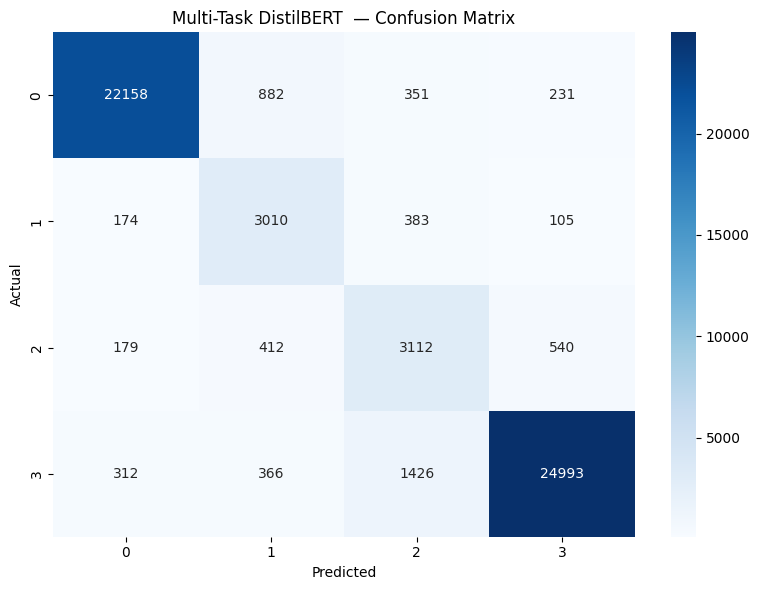

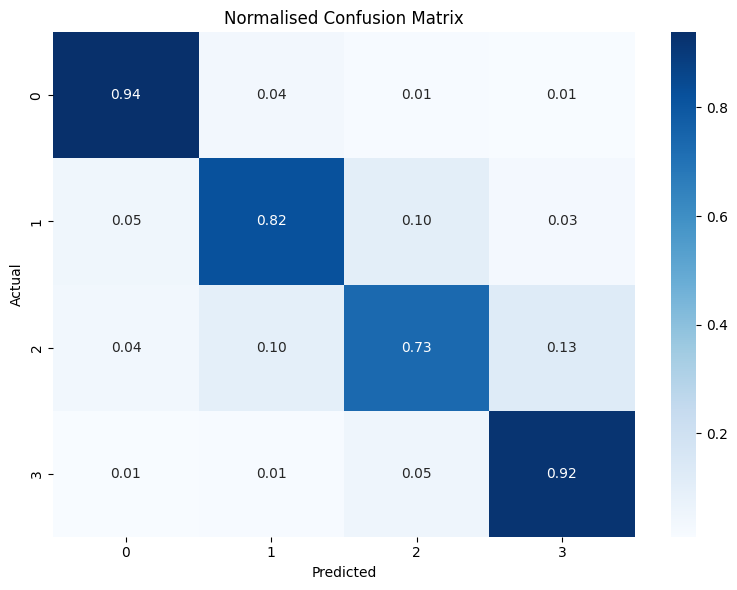

2026-06-03 10:35:11,362 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 10:35:11,363 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


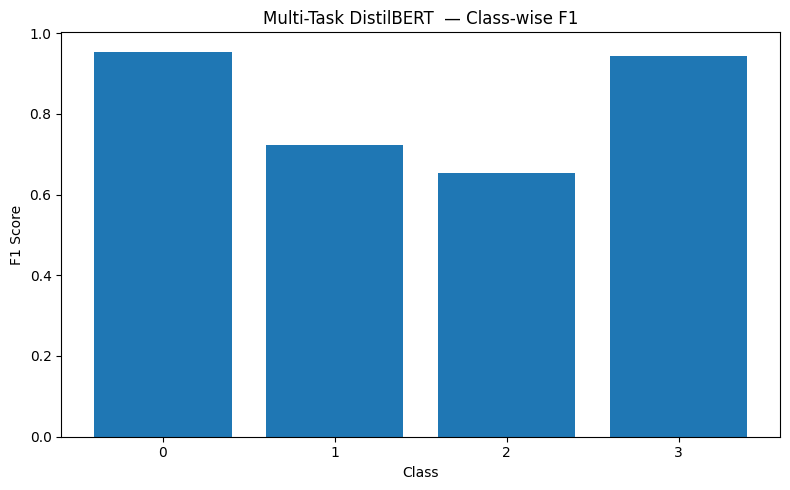



SEVERITY ERROR ANALYSIS
Total Misclassified Samples : 5361


    Index  Actual Label  Predicted Label
0       4             2                0
1      21             3                2
2      22             2                0
3      30             1                2
4      58             3                2
5      94             0                1
6      95             3                2
7     106             2                0
8     110             2                1
9     124             3                2
10    134             0                1
11    154             3                2
12    171             1                0
13    185             2                1
14    196             1                2
15    217             0                1
16    243             3                2
17    247             3                2
18    272             3                2
19    287             3                0


SEVERITY ERROR DISTRIBUTION
    Actual Label  Predicted Label  Count
0    

In [ ]:
# =============================================================================
# — Multi-Task DistilBERT Full Evaluation 
# =============================================================================
 
y_true = severity_true
y_pred = severity_pred
 
accuracy    = accuracy_score(y_true, y_pred)
precision   = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall      = recall_score(y_true, y_pred, average='weighted', zero_division=0)
macro_f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
mae         = mean_absolute_error(y_true, y_pred)
rmse        = np.sqrt(mean_squared_error(y_true, y_pred))
qwk_multi   = cohen_kappa_score(y_true, y_pred, weights='quadratic')
 
print("=" * 80)
print("MULTI-TASK DISTILBERT  — EVALUATION")
print("=" * 80)
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"QWK           : {qwk_multi:.4f}")
 
print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_true, y_pred, zero_division=0))
 

cm = confusion_matrix(y_true, y_pred)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Multi-Task DistilBERT  — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
 

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
plt.title("Normalised Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
 

report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
class_f1 = []
classes  = sorted(list(set(y_true)))
for cls in classes:
    class_f1.append(report[str(cls)]['f1-score'])
 
plt.figure(figsize=(8, 5))
plt.bar([str(c) for c in classes], class_f1)
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Multi-Task DistilBERT  — Class-wise F1")
plt.tight_layout()
plt.show()
 

severity_errors = []
for i in range(len(severity_true)):
    if severity_true[i] != severity_pred[i]:
        severity_errors.append({
            "Index":           i,
            "Actual Label":    severity_true[i],
            "Predicted Label": severity_pred[i]
        })
 
severity_error_df = pd.DataFrame(severity_errors)
 
print("\n")
print("=" * 80)
print("SEVERITY ERROR ANALYSIS")
print("=" * 80)
print(f"Total Misclassified Samples : {len(severity_error_df)}")
print("\n")
 
if len(severity_error_df) > 0:
    print(severity_error_df.head(20))
else:
    print("No Misclassifications Found")
 
if len(severity_error_df) > 0:
    severity_error_summary = severity_error_df.groupby(
        ['Actual Label', 'Predicted Label']
    ).size().reset_index(name='Count')
    print("\n")
    print("=" * 80)
    print("SEVERITY ERROR DISTRIBUTION")
    print("=" * 80)
    
    print(severity_error_summary)

off_by_1 = severity_error_df[np.abs(severity_error_df['Actual Label'] - severity_error_df['Predicted Label']) == 1].shape[0]
off_by_2 = severity_error_df[np.abs(severity_error_df['Actual Label'] - severity_error_df['Predicted Label']) >= 2].shape[0]
print(f"\nOff-by-1 errors : {off_by_1} ({off_by_1/len(severity_error_df)*100:.1f}%)")
print(f"Off-by-2+ errors: {off_by_2} ({off_by_2/len(severity_error_df)*100:.1f}%)")
 
print(final_df.shape)

In [ ]:
# =============================================================================
#  — Store predictions 
# =============================================================================
 


 
print("=" * 80)
print(f"Multi-Task QWK : {qwk_multi:.4f}")
print("=" * 80)
 

Multi-Task QWK : 0.9441


                    Model       QWK
0     Logistic Regression  0.845420
1                     SVM  0.853619
2  Single Task DistilBERT  0.918840
3   Multi Task DistilBERT  0.944073


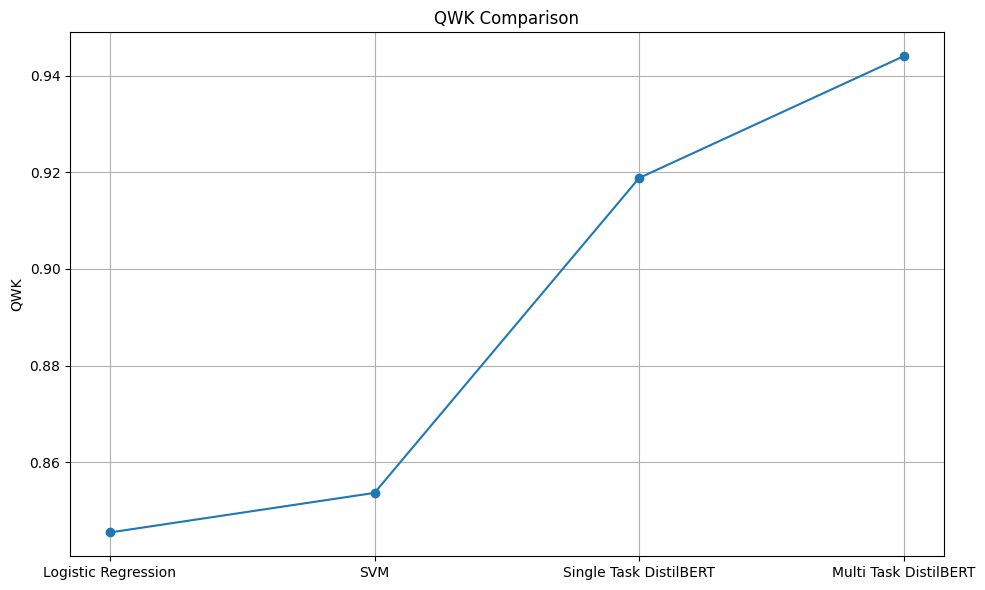

In [ ]:
# =============================================================================
# — QWK comparison table
# =============================================================================
 
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Single Task DistilBERT",
        "Multi Task DistilBERT"
    ],
    "QWK": [
        qwk_lr,
        qwk_svm,
        qwk_single,
        qwk_multi
    ]
})
 
print(results)
 
plt.figure(figsize=(10, 6))
plt.plot(results['Model'], results['QWK'], marker='o')
plt.title("QWK Comparison")
plt.ylabel("QWK")
plt.grid(True)
plt.tight_layout()
plt.show()
 

In [ ]:
# =============================================================================
# — Statistical Testing (McNemar + Wilcoxon + Bootstrap)
# =============================================================================

 
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon
from sklearn.metrics import f1_score
 





def run_mcnemar_test(
    y_true,
    pred1,
    pred2,
    model1_name,
    model2_name
):
    y_true = np.array(y_true)
    pred1  = np.array(pred1)
    pred2  = np.array(pred2)
 
    model1_correct = (pred1 == y_true)
    model2_correct = (pred2 == y_true)
 
    both_correct  = np.sum((model1_correct == True)  & (model2_correct == True))
    model1_only   = np.sum((model1_correct == True)  & (model2_correct == False))
    model2_only   = np.sum((model1_correct == False) & (model2_correct == True))
    both_wrong    = np.sum((model1_correct == False) & (model2_correct == False))
 
    table = [
        [both_correct, model1_only],
        [model2_only,  both_wrong]
    ]
 
    result = mcnemar(table, exact=False, correction=True)
 
    print("\n" + "=" * 60)
    print(f"MCNEMAR TEST: {model1_name} vs {model2_name}")
    print("=" * 60)
    print("\nContingency Table:")
    print(np.array(table))
    print(f"\nStatistic: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.6f}")
 
    if result.pvalue < 0.05:
        print("\nResult: Statistically Significant Difference")
    else:
        print("\nResult: NO Statistically Significant Difference")
 
    return result
 
 


def run_wilcoxon_test(
    pred1,
    pred2,
    model1_name,
    model2_name
):
    pred1 = np.array(pred1)
    pred2 = np.array(pred2)
 
    stat, p = wilcoxon(pred1, pred2)
 
    print("=" * 80)
    print("WILCOXON SIGNED-RANK TEST")
    
    print(f"{model1_name} vs {model2_name}")
    print("=" * 80)
    print("Statistic :", stat)
    print("P-value   :", p)
 
    if p < 0.05:
        print("Result : Significant Difference")
    else:
        print("Result : No Significant Difference")
    print("\n")
 





def bootstrap_metric(
    y_true,
    y_pred,
    metric_function,
    n_bootstrap=1000
):
    scores = []
    n      = len(y_true)
 
    for _ in range(n_bootstrap):
        indices = np.random.choice(range(n), n, replace=True)
        yt      = np.array(y_true)[indices]
        yp      = np.array(y_pred)[indices]
        score   = metric_function(yt, yp)
        scores.append(score)
 
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return lower, upper
 





run_mcnemar_test(
    severity_true,
    severity_pred,
    single_task_preds,
    "Multi-Task DistilBERT",
    "Single-Task DistilBERT"
)
 
run_mcnemar_test(
    severity_true,
    severity_pred,
    logistic_preds,
    "Multi-Task DistilBERT",
    "Logistic Regression"
)
 
run_mcnemar_test(
    severity_true,
    severity_pred,
    linear_svc_preds,
    "Multi-Task DistilBERT",
    "Linear SVC"
)
 
run_wilcoxon_test(
    severity_pred,
    single_task_preds,
    "Multi-Task DistilBERT",
    "Single-Task DistilBERT"
)





lower, upper = bootstrap_metric(
    severity_true,
    severity_pred,
    lambda yt, yp: f1_score(yt, yp, average='macro')
)


print("=" * 80)
print("BOOTSTRAP CONFIDENCE INTERVAL")
print("Multi-Task DistilBERT")
print("=" * 80)
print(f"95% CI : [{lower:.4f}, {upper:.4f}]")





lower, upper = bootstrap_metric(
    severity_true,
    single_task_preds,
    lambda yt, yp: f1_score(yt, yp, average='macro')
)


print("=" * 80)
print("BOOTSTRAP CONFIDENCE INTERVAL")
print("Single-Task DistilBERT")
print("=" * 80)
print(f"95% CI : [{lower:.4f}, {upper:.4f}]")
 
 


MCNEMAR TEST: Multi-Task DistilBERT vs Single-Task DistilBERT

Contingency Table:
[[47503  5770]
 [ 2565  2796]]

Statistic: 1231.6276
P-value: 0.000000

Result: Statistically Significant Difference

MCNEMAR TEST: Multi-Task DistilBERT vs Logistic Regression

Contingency Table:
[[45897  7376]
 [ 1970  3391]]

Statistic: 3125.8319
P-value: 0.000000

Result: Statistically Significant Difference

MCNEMAR TEST: Multi-Task DistilBERT vs Linear SVC

Contingency Table:
[[47362  5911]
 [ 2223  3138]]

Statistic: 1671.2526
P-value: 0.000000

Result: Statistically Significant Difference
WILCOXON SIGNED-RANK TEST
Multi-Task DistilBERT vs Single-Task DistilBERT
Statistic : 20062854.0
P-value   : 2.4269487050951345e-11
Result : Significant Difference


BOOTSTRAP CONFIDENCE INTERVAL
Multi-Task DistilBERT
95% CI : [0.8138, 0.8233]
BOOTSTRAP CONFIDENCE INTERVAL
Single-Task DistilBERT
95% CI : [0.5444, 0.5559]


In [ ]:
# =============================================================================
#  — FINAL MODEL COMPARISON TABLE 
# =============================================================================


def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall":    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Macro_F1":  f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Weighted_F1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "QWK":  cohen_kappa_score(y_true, y_pred, weights='quadratic')
    }


 
multi_task_results  = calculate_metrics(severity_true,        severity_pred)
single_task_results = calculate_metrics(severity_true,        single_task_preds)
lr_results          = calculate_metrics(test_df['severity_label'],  pred_severity)
svc_results         = calculate_metrics(test_df['severity_label'],  svm_pred_severity)

 
comparison_df = pd.DataFrame({
    "Model": [
        "Multi-Task DistilBERT",
        "Single-Task DistilBERT",
        "Logistic Regression",
        "Linear SVC"
    ],
    "Accuracy":    [multi_task_results["Accuracy"],    single_task_results["Accuracy"],    lr_results["Accuracy"],    svc_results["Accuracy"]],
    "Precision":   [multi_task_results["Precision"],   single_task_results["Precision"],   lr_results["Precision"],   svc_results["Precision"]],
    "Recall":      [multi_task_results["Recall"],      single_task_results["Recall"],      lr_results["Recall"],      svc_results["Recall"]],
    "Macro_F1":    [multi_task_results["Macro_F1"],    single_task_results["Macro_F1"],    lr_results["Macro_F1"],    svc_results["Macro_F1"]],
    "Weighted_F1": [multi_task_results["Weighted_F1"], single_task_results["Weighted_F1"], lr_results["Weighted_F1"], svc_results["Weighted_F1"]],
    "MAE":         [multi_task_results["MAE"],         single_task_results["MAE"],         lr_results["MAE"],         svc_results["MAE"]],
    "RMSE":        [multi_task_results["RMSE"],        single_task_results["RMSE"],        lr_results["RMSE"],        svc_results["RMSE"]],
    "QWK":         [multi_task_results["QWK"],         single_task_results["QWK"],         lr_results["QWK"],         svc_results["QWK"]],
})
 
comparison_df = comparison_df.round(4)


comparison_df = comparison_df.sort_values(
    by="QWK",
    ascending=False
).reset_index(drop=True)


print("=" * 120)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 120)
print(comparison_df)


comparison_df.to_csv("final_model_comparison_table.csv", index=False)
print("\nCSV file saved successfully.")


best_model = comparison_df.iloc[0]


print("\n" + "=" * 120)

print("BEST MODEL")

print("=" * 120)
print(f"Model Name  : {best_model['Model']}")
print(f"QWK         : {best_model['QWK']:.4f}")
print(f"Macro F1    : {best_model['Macro_F1']:.4f}")
print(f"Accuracy    : {best_model['Accuracy']:.4f}")
 

FINAL MODEL COMPARISON TABLE
                    Model  Accuracy  Precision  Recall  Macro_F1  Weighted_F1  \
0   Multi-Task DistilBERT    0.9086     0.9207  0.9086    0.8184       0.9131   
1  Single-Task DistilBERT    0.8539     0.8120  0.8539    0.5502       0.8169   
2              Linear SVC    0.8457     0.8457  0.8457    0.7096       0.8448   
3     Logistic Regression    0.8164     0.8518  0.8164    0.6982       0.8285   

      MAE    RMSE     QWK  
0  0.1270  0.4655  0.9441  
1  0.1986  0.5799  0.9188  
2  0.2691  0.7609  0.8536  
3  0.2960  0.7690  0.8454  

CSV file saved successfully.

BEST MODEL
Model Name  : Multi-Task DistilBERT
QWK         : 0.9441
Macro F1    : 0.8184
Accuracy    : 0.9086


In [ ]:
# ──— ERROR ANALYSIS ─────────────────────────────────────────────────
def severity_error_analysis(y_true, y_pred, test_df, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    total_samples = len(y_true)

    errors = []
    for i in range(len(y_true)):
        if y_true[i] != y_pred[i]:
            errors.append({
                "Index":           i,
                "Actual Label":    y_true[i],
                "Predicted Label": y_pred[i]
            })

    error_df = pd.DataFrame(errors)
    SEP = '=' * 70

    
    total_errors    = len(error_df)
    error_rate_pct  = (total_errors / total_samples) * 100
    correct         = total_samples - total_errors
    accuracy_pct    = (correct / total_samples) * 100

    print(f'\n{SEP}')
    print(f'ERROR ANALYSIS -- {model_name}')
    print(f'{SEP}')
    print(f'Total Samples               : {total_samples}')
    print(f'Correctly Classified        : {correct}  ({accuracy_pct:.2f}%)')
    print(f'Total Misclassified Samples : {total_errors}  ({error_rate_pct:.2f}%)')

    error_dist = pd.DataFrame()

    if len(error_df) > 0:
        print(f'\n── Top 20 Misclassified Samples ──')
        print(error_df.head(20).to_string(index=False))

        
        error_dist = error_df.groupby(
            ['Actual Label', 'Predicted Label']
        ).size().reset_index(name='Count')

       
        class_totals = pd.Series(y_true).value_counts().rename('Class Total')
        per_class_errors = (
            error_df.groupby('Actual Label')
            .size()
            .rename('Misclassified')
            .reset_index()
        )
        per_class_errors = per_class_errors.merge(
            class_totals.reset_index().rename(columns={'index': 'Actual Label'}),
            on='Actual Label',
            how='left'
        )
        per_class_errors['Error Rate (%)'] = (
            per_class_errors['Misclassified'] / per_class_errors['Class Total'] * 100
        ).round(2)
        per_class_errors['Correct Rate (%)'] = (
            100 - per_class_errors['Error Rate (%)']
        ).round(2)

        print(f'\n── Error Distribution (Actual → Predicted) ──')
        print(error_dist.to_string(index=False))

        print(f'\n── Per-Class Error Rate ──')
        print(per_class_errors.to_string(index=False))

    return error_df, error_dist


mt_error_df, mt_error_dist = severity_error_analysis(
    severity_true, severity_pred, test_df, "Multi-Task DistilBERT"
)
st_error_df, st_error_dist = severity_error_analysis(
    severity_true, single_task_preds, test_df, "Single-Task DistilBERT"
)

print("\n\nMULTI-TASK vs SINGLE-TASK QWK COMPARISON:")

print(f"  Multi-Task  QWK : {qwk_multi:.4f}")

print(f"  Single-Task QWK : {qwk_single:.4f}")
if qwk_multi > qwk_single:
    print("  ✅ Multi-Task QWK > Single-Task QWK (as expected)")
else:
    print("  ⚠️  Multi-Task QWK ≤ Single-Task — check data quality or increase EPOCHS")


ERROR ANALYSIS -- Multi-Task DistilBERT
Total Samples               : 58634
Correctly Classified        : 53273  (90.86%)
Total Misclassified Samples : 5361  (9.14%)

── Top 20 Misclassified Samples ──
 Index  Actual Label  Predicted Label
     4             2                0
    21             3                2
    22             2                0
    30             1                2
    58             3                2
    94             0                1
    95             3                2
   106             2                0
   110             2                1
   124             3                2
   134             0                1
   154             3                2
   171             1                0
   185             2                1
   196             1                2
   217             0                1
   243             3                2
   247             3                2
   272             3                2
   287             3                0

In [ ]:
# =============================================================================
# CHECKPOINT SAVE —
# =============================================================================


import os
import pickle
import torch
import numpy as np

CKPT_DIR = "/kaggle/working/mtt_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)


CKPT_MODEL_PATH = os.path.join(CKPT_DIR, "checkpoint_model_state.pt")
torch.save(model.state_dict(), CKPT_MODEL_PATH)
print(f"✅ model state dict         → {CKPT_MODEL_PATH}")



CKPT_PREDS_PATH = os.path.join(CKPT_DIR, "checkpoint_predictions.npz")
np.savez(
    CKPT_PREDS_PATH,
    severity_true     = np.array(severity_true),
    severity_pred     = np.array(severity_pred),
    single_task_preds = np.array(single_task_preds),
    pred_severity     = np.array(pred_severity),
    svm_pred_severity = np.array(svm_pred_severity),
)
print(f"✅ prediction arrays        → {CKPT_PREDS_PATH}.npz")



CKPT_METRICS_PATH = os.path.join(CKPT_DIR, "checkpoint_metrics.pkl")
with open(CKPT_METRICS_PATH, "wb") as f:
    pickle.dump({
        "qwk_multi"  : float(qwk_multi),
        "qwk_single" : float(qwk_single),
        "qwk_lr"     : float(qwk_lr),
        "qwk_svm"    : float(qwk_svm),
    }, f)
print(f"✅ scalar metrics           → {CKPT_METRICS_PATH}")



CKPT_DATA_PATH = os.path.join(CKPT_DIR, "checkpoint_dataframes.pkl")
with open(CKPT_DATA_PATH, "wb") as f:
    pickle.dump({
        "train_df"      : train_df,
        "val_df"        : val_df,
        "test_df"       : test_df,
        "comparison_df" : comparison_df,
    }, f)
print(f"✅ dataframes               → {CKPT_DATA_PATH}")



CKPT_SKLEARN_PATH = os.path.join(CKPT_DIR, "checkpoint_sklearn.pkl")
with open(CKPT_SKLEARN_PATH, "wb") as f:
    pickle.dump({
        "tfidf"           : tfidf,
        "lr_severity"     : lr_severity,
        "svm_severity"    : svm_severity,
        "logistic_preds"  : np.array(logistic_preds),
        "linear_svc_preds": np.array(linear_svc_preds),
        "X_train_tfidf"   : X_train_tfidf,
        "X_test_tfidf"    : X_test_tfidf,
    }, f)
print(f"✅ sklearn objects          → {CKPT_SKLEARN_PATH}")


print("\n" + "=" * 70)
print("CHECKPOINT SAVED SUCCESSFULLY")
print("=" * 70)
for fname in sorted(os.listdir(CKPT_DIR)):
    fpath = os.path.join(CKPT_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"  {fname:<48}  {size_mb:.2f} MB")




✅ model state dict         → /kaggle/working/mtt_checkpoints/checkpoint_model_state.pt
✅ prediction arrays        → /kaggle/working/mtt_checkpoints/checkpoint_predictions.npz.npz
✅ scalar metrics           → /kaggle/working/mtt_checkpoints/checkpoint_metrics.pkl
✅ dataframes               → /kaggle/working/mtt_checkpoints/checkpoint_dataframes.pkl
✅ sklearn objects          → /kaggle/working/mtt_checkpoints/checkpoint_sklearn.pkl

CHECKPOINT SAVED SUCCESSFULLY
  checkpoint_dataframes.pkl                         209.73 MB
  checkpoint_metrics.pkl                            0.00 MB
  checkpoint_model_state.pt                         270.39 MB
  checkpoint_predictions.npz                        2.35 MB
  checkpoint_sklearn.pkl                            144.75 MB


2026-06-02 08:50:07,574 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-02 08:50:07,619 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-02 08:50:07,667 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-02 08:50:07,760 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-02 08:50:07,807 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-02 08:50:07,858 [INFO] HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased


A1. MODEL COMPARISON ABLATION
                 Model  Accuracy  Precision  Recall  Macro_F1  Weighted_F1    MAE   RMSE    QWK
 Multi-Task DistilBERT    0.9086     0.9207  0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
Single-Task DistilBERT    0.8539     0.8120  0.8539    0.5502       0.8169 0.1986 0.5799 0.9188
            Linear SVC    0.8457     0.8457  0.8457    0.7096       0.8448 0.2691 0.7609 0.8536
   Logistic Regression    0.8164     0.8518  0.8164    0.6982       0.8285 0.2960 0.7690 0.8454


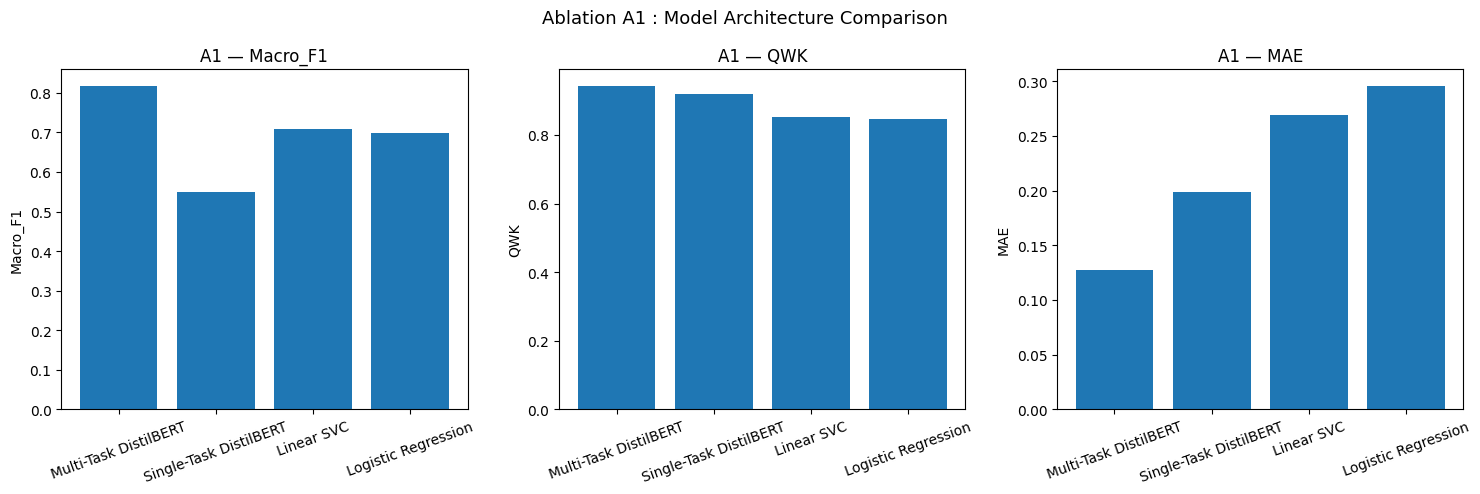

2026-06-02 08:50:09,066 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-02 08:50:09,116 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"



A2. ORDINAL LOSS ABLATION : CORAL vs CrossEntropy

[A2] Training MultiTaskModelCE (CrossEntropy severity) ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 1/5 | Train Loss: 2.3802 | Val QWK: 0.8875
  Epoch 2/5 | Train Loss: 1.9455 | Val QWK: 0.9218
  Epoch 3/5 | Train Loss: 1.8217 | Val QWK: 0.9272
  Epoch 4/5 | Train Loss: 1.7563 | Val QWK: 0.9326
  Epoch 5/5 | Train Loss: 1.7066 | Val QWK: 0.9346

CONFIG : A2 — CrossEntropy Severity
  Accuracy    : 0.9094
  Precision   : 0.9184
  Recall      : 0.9094
  Macro F1    : 0.8250
  Weighted F1 : 0.9128
  MAE         : 0.1374
  RMSE        : 0.5082
  QWK         : 0.9336

A2 SUMMARY:
           Loss  Accuracy  Macro_F1  Weighted_F1    MAE   RMSE    QWK
CORAL (Ordinal)    0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
   CrossEntropy    0.9094    0.8250       0.9128 0.1374 0.5082 0.9336


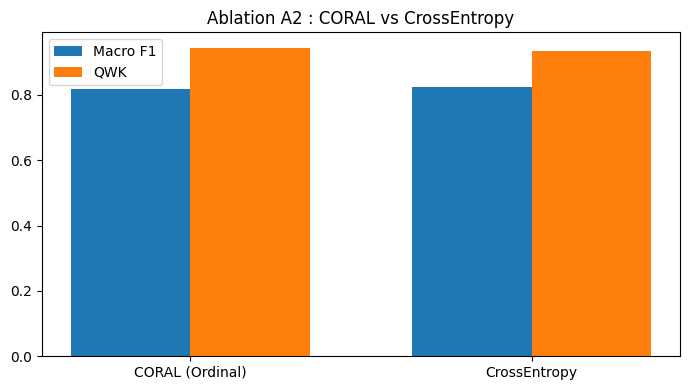

2026-06-02 11:36:37,536 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-02 11:36:37,587 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"



A3. LOSS WEIGHTING STRATEGY : Uncertainty vs Equal

[A3] Training Equal-Weight loss variant ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 1/5 | Train Loss: 2.9623 | Val QWK: 0.9305 | Val Macro F1: 0.7823
  Epoch 2/5 | Train Loss: 2.4916 | Val QWK: 0.9352 | Val Macro F1: 0.7974
  Epoch 3/5 | Train Loss: 2.3899 | Val QWK: 0.9397 | Val Macro F1: 0.8061
  Epoch 4/5 | Train Loss: 2.3212 | Val QWK: 0.9411 | Val Macro F1: 0.8097
  Epoch 5/5 | Train Loss: 2.2526 | Val QWK: 0.9427 | Val Macro F1: 0.8206

CONFIG : A3 — Equal Weighting
  Accuracy    : 0.9086
  Precision   : 0.9204
  Recall      : 0.9086
  Macro F1    : 0.8199
  Weighted F1 : 0.9130
  MAE         : 0.1283
  RMSE        : 0.4707
  QWK         : 0.9428

A3 SUMMARY:
        Loss Strategy  Accuracy  Macro_F1  Weighted_F1    MAE   RMSE    QWK
Uncertainty (Kendall)    0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
      Equal Weighting    0.9086    0.8199       0.9130 0.1283 0.4707 0.9428


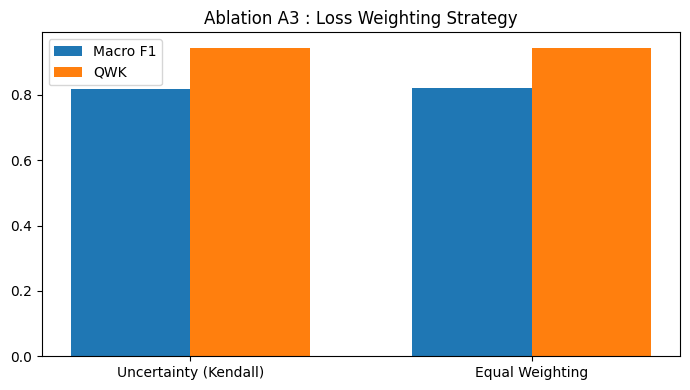


A4. CROSS-TASK GATE ABLATION : With vs Without

[A4] Training without cross-task gate ...


2026-06-02 14:11:38,194 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-02 14:11:38,246 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 1/5 | Train Loss: 2.7377 | Val QWK: 0.9270 | Val Macro F1: 0.7811
  Epoch 2/5 | Train Loss: 2.1300 | Val QWK: 0.9325 | Val Macro F1: 0.7866
  Epoch 3/5 | Train Loss: 2.3867 | Val QWK: 0.9377 | Val Macro F1: 0.8024
  Epoch 4/5 | Train Loss: 3.1405 | Val QWK: 0.9402 | Val Macro F1: 0.8161
  Epoch 5/5 | Train Loss: 3.7620 | Val QWK: 0.9417 | Val Macro F1: 0.8201

CONFIG : A4 — No Cross-Task Gate
  Accuracy    : 0.9101
  Precision   : 0.9208
  Recall      : 0.9101
  Macro F1    : 0.8216
  Weighted F1 : 0.9141
  MAE         : 0.1274
  RMSE        : 0.4716
  QWK         : 0.9427

A4 SUMMARY:
Cross-Task Gate  Accuracy  Macro_F1  Weighted_F1    MAE   RMSE    QWK
      With Gate    0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
   Without Gate    0.9101    0.8216       0.9141 0.1274 0.4716 0.9427


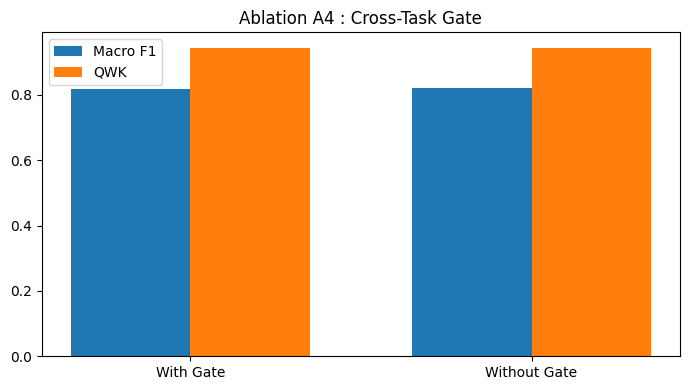

2026-06-02 16:49:01,881 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-02 16:49:01,934 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"



A5. HEAD ARCHITECTURE : Linear vs MLP

[A5] Training Linear Head variant ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 1/5 | Train Loss: 2.7591 | Val QWK: 0.9249 | Val Macro F1: 0.7494
  Epoch 2/5 | Train Loss: 2.0926 | Val QWK: 0.9363 | Val Macro F1: 0.7824
  Epoch 3/5 | Train Loss: 2.1041 | Val QWK: 0.9390 | Val Macro F1: 0.7913
  Epoch 4/5 | Train Loss: 2.5908 | Val QWK: 0.9416 | Val Macro F1: 0.8054
  Epoch 5/5 | Train Loss: 3.1828 | Val QWK: 0.9428 | Val Macro F1: 0.8152

CONFIG : A5 — Linear Head
  Accuracy    : 0.9077
  Precision   : 0.9204
  Recall      : 0.9077
  Macro F1    : 0.8170
  Weighted F1 : 0.9125
  MAE         : 0.1278
  RMSE        : 0.4661
  QWK         : 0.9439

A5 SUMMARY:
Head Architecture  Accuracy  Macro_F1  Weighted_F1    MAE   RMSE    QWK
  MLP Head (main)    0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
      Linear Head    0.9077    0.8170       0.9125 0.1278 0.4661 0.9439


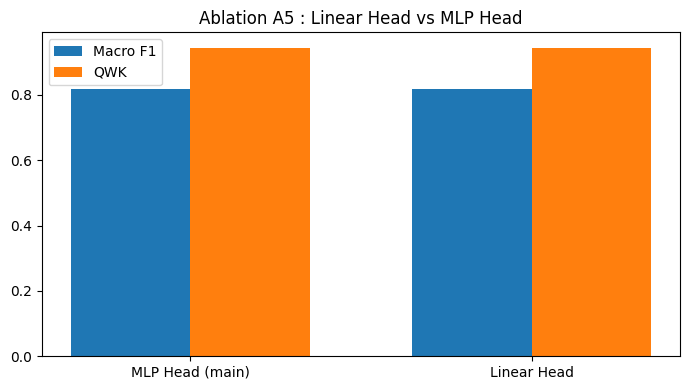


MASTER ABLATION SUMMARY
Ablation            Factor                 Config  Accuracy  Precision  Recall  Macro_F1  Weighted_F1    MAE   RMSE    QWK
      A1        Model Type  Multi-Task DistilBERT    0.9086     0.9207  0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
      A1        Model Type Single-Task DistilBERT    0.8539     0.8120  0.8539    0.5502       0.8169 0.1986 0.5799 0.9188
      A1        Model Type    Logistic Regression    0.8164     0.8518  0.8164    0.6982       0.8285 0.2960 0.7690 0.8454
      A1        Model Type             Linear SVC    0.8457     0.8457  0.8457    0.7096       0.8448 0.2691 0.7609 0.8536
      A2      Ordinal Loss           CORAL (main)    0.9086     0.9207  0.9086    0.8184       0.9131 0.1270 0.4655 0.9441
      A2      Ordinal Loss           CrossEntropy    0.9094     0.9184  0.9094    0.8250       0.9128 0.1374 0.5082 0.9336
      A3    Loss Weighting  Uncertainty (Kendall)    0.9086     0.9207  0.9086    0.8184       0.9131 0.1270 0.465

In [ ]:
# =============================================================================
# ABLATION STUDY — Multi-Task DistilBERT
# =============================================================================
#   A1. Multi-task vs Single-task DistilBERT vs Logistic Regression vs SVM
#   A2. Ordinal Loss — CORAL vs CrossEntropy
#   A3. Loss Weighting Strategy (Uncertainty vs Equal)
#   A4. Cross-Task Gate (With vs Without)
#   A5. Linear Head vs MLP Head
# =============================================================================


import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, mean_absolute_error, mean_squared_error
)
from sklearn.utils.class_weight import compute_class_weight
 
EPOCHS = 5
 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
 

 
class MentalHealthDataset(Dataset):
    """Multi-task dataset (sentiment + severity) — used by multi-task model."""
 
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        text      = self.df.loc[idx, 'text']
        sentiment = self.df.loc[idx, 'sentiment_label']
        severity  = self.df.loc[idx, 'severity_label']
 
        encoding = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
 
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'sentiment':      torch.tensor(sentiment, dtype=torch.long),
            'severity':       torch.tensor(severity,  dtype=torch.long)
        }
 
 
class MentalDataset(Dataset):
    """Single-task dataset — used by baseline models."""
 
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len
 
    def __len__(self):
        return len(self.texts)
 
    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]
 
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
 
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(label, dtype=torch.long)
        }
 
 

 
def make_weighted_sampler(df, label_col='severity_label'):
    """Create a WeightedRandomSampler so every severity class is sampled equally."""
    labels        = df[label_col].values
    class_counts  = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler
 
 

 
train_dataset = MentalHealthDataset(train_df)
val_dataset   = MentalHealthDataset(val_df)
test_dataset  = MentalHealthDataset(test_df)
 
train_sampler = make_weighted_sampler(train_df, label_col='severity_label')
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
 
 

 
sentiment_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['sentiment_label'].values
)
sentiment_class_weights_np = sentiment_class_weights.copy()
sentiment_class_weights = torch.tensor(sentiment_class_weights, dtype=torch.float).to(device)
 
sentiment_loss_fn = nn.CrossEntropyLoss(
    weight=sentiment_class_weights,
    label_smoothing=0.1
)
 
severity_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_df['severity_label'].values
)
severity_class_weights_tensor = torch.tensor(severity_class_weights, dtype=torch.float).to(device)
 
 

 
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall":      recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Macro_F1":    f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Weighted_F1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "MAE":         mean_absolute_error(y_true, y_pred),
        "RMSE":        np.sqrt(mean_squared_error(y_true, y_pred)),
        "QWK":         cohen_kappa_score(y_true, y_pred, weights='quadratic')
    }
 
 
def print_ablation_result(config_name, y_true, y_pred):
    m = calculate_metrics(y_true, y_pred)
    print(f"\n{'=' * 70}")
    print(f"CONFIG : {config_name}")
    print(f"{'=' * 70}")
    print(f"  Accuracy    : {m['Accuracy']:.4f}")
    print(f"  Precision   : {m['Precision']:.4f}")
    print(f"  Recall      : {m['Recall']:.4f}")
    print(f"  Macro F1    : {m['Macro_F1']:.4f}")
    print(f"  Weighted F1 : {m['Weighted_F1']:.4f}")
    print(f"  MAE         : {m['MAE']:.4f}")
    print(f"  RMSE        : {m['RMSE']:.4f}")
    print(f"  QWK         : {m['QWK']:.4f}")
    return m
 
 
# =============================================================================
#  FULL MultiTaskModel
# =============================================================================
 
class MultiTaskModel(nn.Module):
    """
    Multi-Task DistilBERT with:
     - Cross-task attention gate  (sentiment -> severity)
     - Uncertainty-weighted loss  (Kendall et al., 2018)
     - Richer 2-layer task heads with LayerNorm
     - Residual connection in severity branch
    """
 
    def __init__(self, sentiment_classes: int = 3, severity_classes: int = 4):
        super(MultiTaskModel, self).__init__()
 
        self.encoder  = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size   = self.encoder.config.hidden_size   # 768
 
        self.dropout  = nn.Dropout(0.3)
 
        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, sentiment_classes)
        )
 
        self.severity_hidden = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
 
        self.cross_task_gate = nn.Sequential(
            nn.Linear(sentiment_classes, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.Sigmoid()
        )
 
        self.severity_refine = nn.Sequential(
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),   # extra layer
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        self.coral_layer = CoralLayer(size_in=256, num_classes=severity_classes)
 
        self.log_sigma_sentiment = nn.Parameter(torch.zeros(1))
        self.log_sigma_severity  = nn.Parameter(torch.zeros(1))
 
        self.coral_thresholds = nn.Parameter(
            torch.full((severity_classes - 1,), 0.5)
        )
 
    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]
        cls_output = self.dropout(cls_output)
 
        sentiment_logits  = self.sentiment_head(cls_output)
        severity_features = self.severity_hidden(cls_output)
        gate              = self.cross_task_gate(sentiment_logits.detach())
        severity_features = severity_features * gate + severity_features
        severity_features_refined = self.severity_refine(severity_features)
        severity_features_final   = severity_features_refined + severity_features
        severity_logits           = self.coral_layer(severity_features_final)
 
        return sentiment_logits, severity_logits
 
 

 
def compute_uncertainty_loss(
    sentiment_logits,
    severity_logits,
    sentiment_labels,
    severity_levels,
    model,
    sentiment_loss_fn,
    severity_true_labels=None
):
    s1 = model.log_sigma_sentiment
    s2 = model.log_sigma_severity
 
    L_sentiment = sentiment_loss_fn(sentiment_logits, sentiment_labels)
    L_severity  = coral_loss(severity_logits, severity_levels)
 
    if severity_true_labels is not None:
        sev_probs       = torch.sigmoid(severity_logits)
        sev_pred        = torch.sum((sev_probs > 0.5), dim=1).float()
        sev_true        = severity_true_labels.float()
        ordinal_penalty = torch.mean(torch.abs(sev_pred - sev_true) ** 2) * 0.1
    else:
        ordinal_penalty = 0.0
 
    loss = (
        torch.exp(-s1) * L_sentiment + s1
        + torch.exp(-s2) * L_severity  + s2
        + ordinal_penalty
    )
 
    return loss, L_sentiment, L_severity
 
 

 
def evaluate_on_loader(model, loader, device):
    """Returns (severity_qwk, severity_macro_f1, avg_total_loss)."""
    model.eval()
 
    all_sev_true   = []
    all_sev_pred   = []
    total_loss_val = 0.0
 
    thresholds = torch.clamp(model.coral_thresholds, 0.1, 0.9).detach()
 
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            sentiment_lbl  = batch['sentiment'].to(device)
            severity_lbl   = batch['severity'].to(device)
 
            severity_levels = levels_from_labelbatch(
                severity_lbl, num_classes=4
            ).float().to(device)
 
            with autocast():
                sentiment_logits, severity_logits = model(input_ids, attention_mask)
                loss, _, _ = compute_uncertainty_loss(
                    sentiment_logits, severity_logits,
                    sentiment_lbl, severity_levels,
                    model, sentiment_loss_fn,
                    severity_true_labels=severity_lbl
                )
 
            total_loss_val += loss.item()
 
            sev_probs = torch.sigmoid(severity_logits)
            sev_pred  = torch.sum(
                sev_probs > thresholds.to(device), dim=1
            ).cpu().numpy()
 
            all_sev_true.extend(severity_lbl.cpu().numpy())
            all_sev_pred.extend(sev_pred)
 
    avg_loss = total_loss_val / len(loader)
    qwk      = cohen_kappa_score(all_sev_true, all_sev_pred, weights='quadratic')
    macro_f1 = f1_score(all_sev_true, all_sev_pred, average='macro', zero_division=0)
 
    return qwk, macro_f1, avg_loss
 
 

 
def train_multitask_model(
    model,
    train_loader,
    val_loader,
    epochs,
    sentiment_loss_fn,
    device,
    use_amp=True,
    use_uncertainty_loss=True,
    save_path="/kaggle/working/ablation_model.pt"
):
    """
    Generic training loop used across ablation experiments.
    Parameters
    ----------
    use_amp               : bool — if False, no GradScaler / autocast (fp32)
    use_uncertainty_loss  : bool — if False, uses simple equal-weight sum
    """
    encoder_params = list(model.encoder.parameters())
    head_params    = [p for n, p in model.named_parameters()
                      if not n.startswith('encoder.')]
 
    optimizer = AdamW([
        {"params": encoder_params, "lr": 2e-5,  "weight_decay": 0.01},
        {"params": head_params,    "lr": 5e-4,  "weight_decay": 0.01},
    ])
 
    total_steps = len(train_loader) * epochs
 
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
 
    scaler               = GradScaler() if use_amp else None
    early_stop_patience  = 3
    best_val_qwk         = -1.0
    patience_counter     = 0
 
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
 
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            sentiment      = batch['sentiment'].to(device)
            severity       = batch['severity'].to(device)
 
            severity_levels = levels_from_labelbatch(
                severity, num_classes=4
            ).float().to(device)
 
            optimizer.zero_grad()
 
            if use_amp:
                with autocast():
                    sentiment_logits, severity_logits = model(input_ids, attention_mask)
 
                    if use_uncertainty_loss:
                        loss, _, _ = compute_uncertainty_loss(
                            sentiment_logits, severity_logits,
                            sentiment, severity_levels,
                            model, sentiment_loss_fn,
                            severity_true_labels=severity
                        )
                    else:
                        L_sent = sentiment_loss_fn(sentiment_logits, sentiment)
                        L_sev  = coral_loss(severity_logits, severity_levels)
                        loss   = L_sent + L_sev
 
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
 
            else:
               
                sentiment_logits, severity_logits = model(input_ids, attention_mask)
 
                if use_uncertainty_loss:
                    loss, _, _ = compute_uncertainty_loss(
                        sentiment_logits, severity_logits,
                        sentiment, severity_levels,
                        model, sentiment_loss_fn,
                        severity_true_labels=severity
                    )
                else:
                    L_sent = sentiment_loss_fn(sentiment_logits, sentiment)
                    L_sev  = coral_loss(severity_logits, severity_levels)
                    loss   = L_sent + L_sev
 
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
 
            scheduler.step()
            total_loss += loss.item()
 
        avg_loss = total_loss / len(train_loader)
 
        val_qwk, val_macro_f1, val_loss = evaluate_on_loader(model, val_loader, device)
 
        print(f"  Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} "
              f"| Val QWK: {val_qwk:.4f} | Val Macro F1: {val_macro_f1:.4f}")
 
        if val_qwk > best_val_qwk:
            best_val_qwk     = val_qwk
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
 
    model.load_state_dict(torch.load(save_path, map_location=device))
    return model
 
 
def get_multitask_test_preds(model, test_loader, device):
    """Runs inference on test_loader; returns (severity_true, severity_pred) arrays."""
    model.eval()
    severity_true = []
    severity_pred = []
 
    final_thresholds = torch.clamp(model.coral_thresholds, 0.1, 0.9).detach()
 
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            severity_lbl   = batch['severity']
 
            sentiment_logits, severity_logits = model(input_ids, attention_mask)
 
            sev_probs = torch.sigmoid(severity_logits)
            sev_preds = torch.sum(
                sev_probs > final_thresholds.to(device), dim=1
            ).cpu().numpy()
 
            severity_pred.extend(sev_preds)
            severity_true.extend(severity_lbl.numpy())
 
    return np.array(severity_true), np.array(severity_pred)
 
 
# =============================================================================
#  A1. MULTI-TASK vs SINGLE-TASK vs LOGISTIC REGRESSION vs SVM
# =============================================================================
 
print("\n" + "=" * 70)
print("A1. MODEL COMPARISON ABLATION")
print("=" * 70)
 
 
multi_task_metrics  = calculate_metrics(severity_true,       severity_pred)
single_task_metrics = calculate_metrics(severity_true,       single_task_preds)
lr_metrics          = calculate_metrics(test_df['severity_label'], pred_severity)
svc_metrics         = calculate_metrics(test_df['severity_label'], svm_pred_severity)
 
a1_df = pd.DataFrame({
    "Model": [
        "Multi-Task DistilBERT",
        "Single-Task DistilBERT",
        "Logistic Regression",
        "Linear SVC"
    ],
    "Accuracy":    [multi_task_metrics["Accuracy"],    single_task_metrics["Accuracy"],    lr_metrics["Accuracy"],    svc_metrics["Accuracy"]],
    "Precision":   [multi_task_metrics["Precision"],   single_task_metrics["Precision"],   lr_metrics["Precision"],   svc_metrics["Precision"]],
    "Recall":      [multi_task_metrics["Recall"],      single_task_metrics["Recall"],      lr_metrics["Recall"],      svc_metrics["Recall"]],
    "Macro_F1":    [multi_task_metrics["Macro_F1"],    single_task_metrics["Macro_F1"],    lr_metrics["Macro_F1"],    svc_metrics["Macro_F1"]],
    "Weighted_F1": [multi_task_metrics["Weighted_F1"], single_task_metrics["Weighted_F1"], lr_metrics["Weighted_F1"], svc_metrics["Weighted_F1"]],
    "MAE":         [multi_task_metrics["MAE"],         single_task_metrics["MAE"],         lr_metrics["MAE"],         svc_metrics["MAE"]],
    "RMSE":        [multi_task_metrics["RMSE"],        single_task_metrics["RMSE"],        lr_metrics["RMSE"],        svc_metrics["RMSE"]],
    "QWK":         [multi_task_metrics["QWK"],         single_task_metrics["QWK"],         lr_metrics["QWK"],         svc_metrics["QWK"]],
}).round(4)
 
a1_df = a1_df.sort_values("QWK", ascending=False).reset_index(drop=True)
print(a1_df.to_string(index=False))
a1_df.to_csv("/kaggle/working/ablation_a1_model_comparison.csv", index=False)
 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ["Macro_F1", "QWK", "MAE"]):
    ax.bar(a1_df["Model"], a1_df[metric])
    ax.set_title(f"A1 — {metric}")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle("Ablation A1 : Model Architecture Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_a1_model_comparison.png", dpi=150)
plt.show()
 
 
# =============================================================================
#  A2. ORDINAL LOSS — CORAL vs CrossEntropy (on Severity)
# =============================================================================

 
print("\n" + "=" * 70)
print("A2. ORDINAL LOSS ABLATION : CORAL vs CrossEntropy")
print("=" * 70)
 
 
class MultiTaskModelCE(nn.Module):
    """
    Same as MultiTaskModel but severity head outputs raw logits for
    CrossEntropyLoss instead of a CORAL layer.
    """
 
    def __init__(self, sentiment_classes: int = 3, severity_classes: int = 4):
        super(MultiTaskModelCE, self).__init__()
 
        self.encoder  = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size   = self.encoder.config.hidden_size
 
        self.dropout  = nn.Dropout(0.3)
 
        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, sentiment_classes)
        )
 
        self.severity_hidden = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
 
        self.cross_task_gate = nn.Sequential(
            nn.Linear(sentiment_classes, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.Sigmoid()
        )
 
        self.severity_refine = nn.Sequential(
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
 
        
        self.severity_ce_head = nn.Linear(256, severity_classes)
 
        
        self.log_sigma_sentiment = nn.Parameter(torch.zeros(1))
        self.log_sigma_severity  = nn.Parameter(torch.zeros(1))
        self.coral_thresholds    = nn.Parameter(torch.full((severity_classes - 1,), 0.5))
 
    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]
        cls_output = self.dropout(cls_output)
 
        sentiment_logits  = self.sentiment_head(cls_output)
        severity_features = self.severity_hidden(cls_output)
        gate              = self.cross_task_gate(sentiment_logits.detach())
        severity_features = severity_features * gate + severity_features
 
        severity_features_refined = self.severity_refine(severity_features)
        severity_features_final   = severity_features_refined + severity_features
        severity_logits           = self.severity_ce_head(severity_features_final)
 
        return sentiment_logits, severity_logits
 
 
def train_multitask_ce_model(model, train_loader, val_loader, epochs, device,
                              save_path="/kaggle/working/ablation_ce_model.pt"):
    """Training loop for CrossEntropy severity variant."""
    severity_ce_loss_fn = nn.CrossEntropyLoss(
        weight=severity_class_weights_tensor,
        label_smoothing=0.1
    )
 
    encoder_params = list(model.encoder.parameters())
    head_params    = [p for n, p in model.named_parameters()
                      if not n.startswith('encoder.')]
 
    optimizer = AdamW([
        {"params": encoder_params, "lr": 2e-5,  "weight_decay": 0.01},
        {"params": head_params,    "lr": 5e-4,  "weight_decay": 0.01},
    ])
 
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
 
    scaler              = GradScaler()
    early_stop_patience = 3
    best_val_qwk        = -1.0
    patience_counter    = 0
 
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
 
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            sentiment      = batch['sentiment'].to(device)
            severity       = batch['severity'].to(device)
 
            optimizer.zero_grad()
 
            with autocast():
                sentiment_logits, severity_logits = model(input_ids, attention_mask)
 
               
                s1 = model.log_sigma_sentiment
                s2 = model.log_sigma_severity
                L_sent = sentiment_loss_fn(sentiment_logits, sentiment)
                L_sev  = severity_ce_loss_fn(severity_logits, severity)
                loss   = torch.exp(-s1) * L_sent + s1 + torch.exp(-s2) * L_sev + s2
 
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += loss.item()
 
        avg_loss = total_loss / len(train_loader)
 
        
        model.eval()
        all_sev_true, all_sev_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                severity_lbl   = batch['severity'].to(device)
 
                _, severity_logits = model(input_ids, attention_mask)
                sev_preds = torch.argmax(severity_logits, dim=1).cpu().numpy()
 
                all_sev_true.extend(severity_lbl.cpu().numpy())
                all_sev_pred.extend(sev_preds)
 
        val_qwk = cohen_kappa_score(all_sev_true, all_sev_pred, weights='quadratic')
 
        print(f"  Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val QWK: {val_qwk:.4f}")
 
        if val_qwk > best_val_qwk:
            best_val_qwk     = val_qwk
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
 
    model.load_state_dict(torch.load(save_path, map_location=device))
    return model
 
 
def get_ce_test_preds(model, test_loader, device):
    model.eval()
    severity_true, severity_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            severity_lbl   = batch['severity']
            _, severity_logits = model(input_ids, attention_mask)
            sev_preds = torch.argmax(severity_logits, dim=1).cpu().numpy()
            severity_pred.extend(sev_preds)
            severity_true.extend(severity_lbl.numpy())
    return np.array(severity_true), np.array(severity_pred)
 
 

print("\n[A2] Training MultiTaskModelCE (CrossEntropy severity) ...")
set_seed(SEED)
model_ce = MultiTaskModelCE(sentiment_classes=3, severity_classes=4).to(device)
model_ce = train_multitask_ce_model(
    model_ce, train_loader, val_loader, EPOCHS, device,
    save_path="/kaggle/working/ablation_a2_ce_model.pt"
)
 
a2_true_ce, a2_pred_ce = get_ce_test_preds(model_ce, test_loader, device)
m_ce = print_ablation_result("A2 — CrossEntropy Severity", a2_true_ce, a2_pred_ce)
 

m_coral = multi_task_metrics
 
a2_df = pd.DataFrame({
    "Loss":        ["CORAL (Ordinal)", "CrossEntropy"],
    "Accuracy":    [m_coral["Accuracy"],    m_ce["Accuracy"]],
    "Macro_F1":    [m_coral["Macro_F1"],    m_ce["Macro_F1"]],
    "Weighted_F1": [m_coral["Weighted_F1"], m_ce["Weighted_F1"]],
    "MAE":         [m_coral["MAE"],         m_ce["MAE"]],
    "RMSE":        [m_coral["RMSE"],        m_ce["RMSE"]],
    "QWK":         [m_coral["QWK"],         m_ce["QWK"]],
}).round(4)
 
print("\nA2 SUMMARY:")
print(a2_df.to_string(index=False))
a2_df.to_csv("/kaggle/working/ablation_a2_loss_type.csv", index=False)
 
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(a2_df))
width = 0.35
ax.bar(x - width/2, a2_df["Macro_F1"], width, label="Macro F1")
ax.bar(x + width/2, a2_df["QWK"],      width, label="QWK")
ax.set_xticks(x)
ax.set_xticklabels(a2_df["Loss"])
ax.set_title("Ablation A2 : CORAL vs CrossEntropy")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_a2_loss_type.png", dpi=150)
plt.show()
 
 
# =============================================================================
#  A3. LOSS WEIGHTING STRATEGY — Uncertainty (Kendall) vs Equal Weighting
# =============================================================================
 
print("\n" + "=" * 70)
print("A3. LOSS WEIGHTING STRATEGY : Uncertainty vs Equal")
print("=" * 70)
 

print("\n[A3] Training Equal-Weight loss variant ...")
set_seed(SEED)
model_equal = MultiTaskModel(sentiment_classes=3, severity_classes=4).to(device)
model_equal = train_multitask_model(
    model_equal, train_loader, val_loader, EPOCHS,
    sentiment_loss_fn, device, use_amp=True, use_uncertainty_loss=False,
    save_path="/kaggle/working/ablation_a3_equal_loss.pt"
)
a3_true_eq, a3_pred_eq = get_multitask_test_preds(model_equal, test_loader, device)
m_eq = print_ablation_result("A3 — Equal Weighting", a3_true_eq, a3_pred_eq)
 

m_unc = multi_task_metrics
 
a3_df = pd.DataFrame({
    "Loss Strategy":  ["Uncertainty (Kendall)", "Equal Weighting"],
    "Accuracy":       [m_unc["Accuracy"],    m_eq["Accuracy"]],
    "Macro_F1":       [m_unc["Macro_F1"],    m_eq["Macro_F1"]],
    "Weighted_F1":    [m_unc["Weighted_F1"], m_eq["Weighted_F1"]],
    "MAE":            [m_unc["MAE"],         m_eq["MAE"]],
    "RMSE":           [m_unc["RMSE"],        m_eq["RMSE"]],
    "QWK":            [m_unc["QWK"],         m_eq["QWK"]],
}).round(4)
 
print("\nA3 SUMMARY:")
print(a3_df.to_string(index=False))
a3_df.to_csv("/kaggle/working/ablation_a3_loss_weighting.csv", index=False)
 
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(a3_df))
width = 0.35
ax.bar(x - width/2, a3_df["Macro_F1"], width, label="Macro F1")
ax.bar(x + width/2, a3_df["QWK"],      width, label="QWK")
ax.set_xticks(x)
ax.set_xticklabels(a3_df["Loss Strategy"])
ax.set_title("Ablation A3 : Loss Weighting Strategy")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_a3_loss_weighting.png", dpi=150)
plt.show()
 
 
# =============================================================================
#  A4. CROSS-TASK GATE — With vs Without
# =============================================================================
 
print("\n" + "=" * 70)
print("A4. CROSS-TASK GATE ABLATION : With vs Without")
print("=" * 70)
 
 
class MultiTaskModelNoGate(nn.Module):
    """
    Identical to MultiTaskModel but with the cross_task_gate removed.
    Severity features flow directly from severity_hidden to severity_refine
    without any sentiment-conditioned gating.
    """
 
    def __init__(self, sentiment_classes: int = 3, severity_classes: int = 4):
        super(MultiTaskModelNoGate, self).__init__()
 
        self.encoder  = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size   = self.encoder.config.hidden_size
 
        self.dropout  = nn.Dropout(0.3)
 
        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, sentiment_classes)
        )
 
        self.severity_hidden = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
 
        
        self.severity_refine = nn.Sequential(
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
 
        self.coral_layer = CoralLayer(size_in=256, num_classes=severity_classes)
 
        self.log_sigma_sentiment = nn.Parameter(torch.zeros(1))
        self.log_sigma_severity  = nn.Parameter(torch.zeros(1))
        self.coral_thresholds    = nn.Parameter(
            torch.full((severity_classes - 1,), 0.5)
        )
 
    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]
        cls_output = self.dropout(cls_output)
 
        sentiment_logits  = self.sentiment_head(cls_output)
        severity_features = self.severity_hidden(cls_output)
 
        
        severity_features_refined = self.severity_refine(severity_features)
        severity_features_final   = severity_features_refined + severity_features
        severity_logits           = self.coral_layer(severity_features_final)
 
        return sentiment_logits, severity_logits
 
 
print("\n[A4] Training without cross-task gate ...")
set_seed(SEED)
model_no_gate = MultiTaskModelNoGate(sentiment_classes=3, severity_classes=4).to(device)
model_no_gate = train_multitask_model(
    model_no_gate, train_loader, val_loader, EPOCHS,
    sentiment_loss_fn, device, use_amp=True, use_uncertainty_loss=True,
    save_path="/kaggle/working/ablation_a4_no_gate.pt"
)
a4_true_ng, a4_pred_ng = get_multitask_test_preds(model_no_gate, test_loader, device)
m_ng = print_ablation_result("A4 — No Cross-Task Gate", a4_true_ng, a4_pred_ng)
 

m_wg = multi_task_metrics
 
a4_df = pd.DataFrame({
    "Cross-Task Gate": ["With Gate", "Without Gate"],
    "Accuracy":        [m_wg["Accuracy"],    m_ng["Accuracy"]],
    "Macro_F1":        [m_wg["Macro_F1"],    m_ng["Macro_F1"]],
    "Weighted_F1":     [m_wg["Weighted_F1"], m_ng["Weighted_F1"]],
    "MAE":             [m_wg["MAE"],         m_ng["MAE"]],
    "RMSE":            [m_wg["RMSE"],        m_ng["RMSE"]],
    "QWK":             [m_wg["QWK"],         m_ng["QWK"]],
}).round(4)
 
print("\nA4 SUMMARY:")
print(a4_df.to_string(index=False))
a4_df.to_csv("/kaggle/working/ablation_a4_cross_task_gate.csv", index=False)
 
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(a4_df))
width = 0.35
ax.bar(x - width/2, a4_df["Macro_F1"], width, label="Macro F1")
ax.bar(x + width/2, a4_df["QWK"],      width, label="QWK")
ax.set_xticks(x)
ax.set_xticklabels(a4_df["Cross-Task Gate"])
ax.set_title("Ablation A4 : Cross-Task Gate")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_a4_cross_task_gate.png", dpi=150)
plt.show()
 
 
# =============================================================================
#  A5. LINEAR HEAD vs MLP HEAD
# =============================================================================
 
print("\n" + "=" * 70)
print("A5. HEAD ARCHITECTURE : Linear vs MLP")
print("=" * 70)
 
 
class MultiTaskModelLinearHead(nn.Module):
    """
    Same as MultiTaskModel but both task heads are single Linear layers
    (no hidden layers, no LayerNorm, no GELU) — the 'linear head' ablation.
    """
 
    def __init__(self, sentiment_classes: int = 3, severity_classes: int = 4):
        super(MultiTaskModelLinearHead, self).__init__()
 
        self.encoder  = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size   = self.encoder.config.hidden_size
 
        self.dropout  = nn.Dropout(0.3)
 
        
        self.sentiment_head = nn.Linear(hidden_size, sentiment_classes)
 
        
        self.severity_proj  = nn.Linear(hidden_size, 256)
 
        
        self.cross_task_gate = nn.Sequential(
            nn.Linear(sentiment_classes, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.Sigmoid()
        )
 
        self.coral_layer = CoralLayer(size_in=256, num_classes=severity_classes)
 
        self.log_sigma_sentiment = nn.Parameter(torch.zeros(1))
        self.log_sigma_severity  = nn.Parameter(torch.zeros(1))
        self.coral_thresholds    = nn.Parameter(
            torch.full((severity_classes - 1,), 0.5)
        )
 
    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]
        cls_output = self.dropout(cls_output)
 
        sentiment_logits  = self.sentiment_head(cls_output)
        severity_features = self.severity_proj(cls_output)
 
        gate              = self.cross_task_gate(sentiment_logits.detach())
        severity_features = severity_features * gate + severity_features
 
        severity_logits   = self.coral_layer(severity_features)
 
        return sentiment_logits, severity_logits
 
 
print("\n[A5] Training Linear Head variant ...")
set_seed(SEED)
model_lin = MultiTaskModelLinearHead(sentiment_classes=3, severity_classes=4).to(device)
model_lin = train_multitask_model(
    model_lin, train_loader, val_loader, EPOCHS,
    sentiment_loss_fn, device, use_amp=True, use_uncertainty_loss=True,
    save_path="/kaggle/working/ablation_a5_linear_head.pt"
)
a5_true_lin, a5_pred_lin = get_multitask_test_preds(model_lin, test_loader, device)
m_lin = print_ablation_result("A5 — Linear Head", a5_true_lin, a5_pred_lin)
 

m_mlp = multi_task_metrics
 
a5_df = pd.DataFrame({
    "Head Architecture": ["MLP Head (main)", "Linear Head"],
    "Accuracy":          [m_mlp["Accuracy"],    m_lin["Accuracy"]],
    "Macro_F1":          [m_mlp["Macro_F1"],    m_lin["Macro_F1"]],
    "Weighted_F1":       [m_mlp["Weighted_F1"], m_lin["Weighted_F1"]],
    "MAE":               [m_mlp["MAE"],         m_lin["MAE"]],
    "RMSE":              [m_mlp["RMSE"],        m_lin["RMSE"]],
    "QWK":               [m_mlp["QWK"],         m_lin["QWK"]],
}).round(4)
 
print("\nA5 SUMMARY:")
print(a5_df.to_string(index=False))
a5_df.to_csv("/kaggle/working/ablation_a5_head_architecture.csv", index=False)
 
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(a5_df))
width = 0.35
ax.bar(x - width/2, a5_df["Macro_F1"], width, label="Macro F1")
ax.bar(x + width/2, a5_df["QWK"],      width, label="QWK")
ax.set_xticks(x)
ax.set_xticklabels(a5_df["Head Architecture"])
ax.set_title("Ablation A5 : Linear Head vs MLP Head")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_a5_head_architecture.png", dpi=150)
plt.show()
 
 
# =============================================================================
#  MASTER ABLATION SUMMARY TABLE
# =============================================================================
 
print("\n" + "=" * 100)
print("MASTER ABLATION SUMMARY")
print("=" * 100)
 
ablation_summary = pd.DataFrame([
    # A1
    {"Ablation": "A1", "Factor": "Model Type", "Config": "Multi-Task DistilBERT",  **{k: v for k, v in multi_task_metrics.items()}},
    {"Ablation": "A1", "Factor": "Model Type", "Config": "Single-Task DistilBERT", **{k: v for k, v in single_task_metrics.items()}},
    {"Ablation": "A1", "Factor": "Model Type", "Config": "Logistic Regression",    **{k: v for k, v in lr_metrics.items()}},
    {"Ablation": "A1", "Factor": "Model Type", "Config": "Linear SVC",             **{k: v for k, v in svc_metrics.items()}},
    # A2
    {"Ablation": "A2", "Factor": "Ordinal Loss",   "Config": "CORAL (main)",     **{k: v for k, v in m_coral.items()}},
    {"Ablation": "A2", "Factor": "Ordinal Loss",   "Config": "CrossEntropy",     **{k: v for k, v in m_ce.items()}},
    # A3
    {"Ablation": "A3", "Factor": "Loss Weighting", "Config": "Uncertainty (Kendall)", **{k: v for k, v in m_unc.items()}},
    {"Ablation": "A3", "Factor": "Loss Weighting", "Config": "Equal Weighting",       **{k: v for k, v in m_eq.items()}},
    # A4
    {"Ablation": "A4", "Factor": "Cross-Task Gate", "Config": "With Gate (main)", **{k: v for k, v in m_wg.items()}},
    {"Ablation": "A4", "Factor": "Cross-Task Gate", "Config": "Without Gate",     **{k: v for k, v in m_ng.items()}},
    # A5
    {"Ablation": "A5", "Factor": "Head Architecture", "Config": "MLP Head (main)", **{k: v for k, v in m_mlp.items()}},
    {"Ablation": "A5", "Factor": "Head Architecture", "Config": "Linear Head",     **{k: v for k, v in m_lin.items()}},
])
 
ablation_summary = ablation_summary[[
    "Ablation", "Factor", "Config",
    "Accuracy", "Precision", "Recall",
    "Macro_F1", "Weighted_F1",
    "MAE", "RMSE", "QWK"
]].round(4)
 
print(ablation_summary.to_string(index=False))
ablation_summary.to_csv("/kaggle/working/ablation_master_summary.csv", index=False)
print("\n✅ All ablation CSVs and plots saved ")